In [28]:
# ============================================================
# SECTION 1: PROJECT OVERVIEW
# ============================================================

"""
Project:
Multi-Agent AI Framework for Fossil Fuel Displacement

Agent:
Energy Demand Agent

Research Question:
Can hybrid ensemble learning models improve India's national electricity demand forecasting
compared with traditional machine learning models using historical state-wise and regional
electricity consumption data?

Dataset:
India's Electricity Consumption Dataset

Important Dataset Note:
The dataset already contains a column named "Total Consumption".
This column represents national-level electricity demand.
Therefore, we rename it to "National_Total_Demand" and use it as the target.

We do NOT create the target by summing state columns again.

Target:
National_Total_Demand

Coordinator Output:
This agent returns predicted demand, demand gap, confidence score, risk level,
and recommended action for the Coordinator Agent.
"""

'\nProject:\nMulti-Agent AI Framework for Fossil Fuel Displacement\n\nAgent:\nEnergy Demand Agent\n\nResearch Question:\nCan hybrid ensemble learning models improve India\'s national electricity demand forecasting\ncompared with traditional machine learning models using historical state-wise and regional\nelectricity consumption data?\n\nDataset:\nIndia\'s Electricity Consumption Dataset\n\nImportant Dataset Note:\nThe dataset already contains a column named "Total Consumption".\nThis column represents national-level electricity demand.\nTherefore, we rename it to "National_Total_Demand" and use it as the target.\n\nWe do NOT create the target by summing state columns again.\n\nTarget:\nNational_Total_Demand\n\nCoordinator Output:\nThis agent returns predicted demand, demand gap, confidence score, risk level,\nand recommended action for the Coordinator Agent.\n'

In [29]:
# ============================================================
# SECTION 2: IMPORTS AND CONFIGURATION
# ============================================================

import os
import sys
import json
import time
import platform
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import joblib

import sklearn
import xgboost

from sklearn.base import BaseEstimator, RegressorMixin, clone

from sklearn.model_selection import (
    TimeSeriesSplit,
    GridSearchCV,
    cross_val_score,
    learning_curve
)

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression

from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    VotingRegressor,
    StackingRegressor
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    median_absolute_error,
    explained_variance_score
)

from sklearn.feature_selection import mutual_info_regression
from sklearn.inspection import permutation_importance

from xgboost import XGBRegressor

try:
    from lightgbm import LGBMRegressor
    LIGHTGBM_AVAILABLE = True
except Exception:
    LIGHTGBM_AVAILABLE = False

try:
    from catboost import CatBoostRegressor
    CATBOOST_AVAILABLE = True
except Exception:
    CATBOOST_AVAILABLE = False

try:
    import shap
    SHAP_AVAILABLE = True
except Exception:
    SHAP_AVAILABLE = False

try:
    import scipy.stats as stats
    SCIPY_AVAILABLE = True
except Exception:
    SCIPY_AVAILABLE = False

try:
    from fpdf import FPDF
    FPDF_AVAILABLE = True
except Exception:
    FPDF_AVAILABLE = False

warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11

RANDOM_STATE = 42
N_SPLITS = 5

ENABLE_SHAP = True
ENABLE_LEARNING_CURVE = True

In [30]:
# ============================================================
# SECTION 3: DATASET PATH
# ============================================================

DATASET_FOLDER = r"E:\Multi_agentic_AI_Project\Dataset\energy_demand_dataset"
DATASET_FILE = "Indias_Electricity_Consumption_Dataset.csv"

DATASET_PATH = os.path.join(DATASET_FOLDER, DATASET_FILE)

if not os.path.exists(DATASET_PATH):
    csv_files = [
        file for file in os.listdir(DATASET_FOLDER)
        if file.lower().endswith(".csv")
    ]

    if len(csv_files) == 0:
        raise FileNotFoundError("No CSV file found in energy_demand_dataset folder.")

    DATASET_PATH = os.path.join(DATASET_FOLDER, csv_files[0])

print("Dataset Path:", DATASET_PATH)

Dataset Path: E:\Multi_agentic_AI_Project\Dataset\energy_demand_dataset\Indias_Electricity_Consumption_Dataset.csv


In [31]:
# ============================================================
# SECTION 4: UTILITY FUNCTIONS
# ============================================================

def save_json(data, file_name):
    with open(file_name, "w") as file:
        json.dump(data, file, indent=4)


def calculate_mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    mask = y_true != 0

    if mask.sum() == 0:
        return np.nan

    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


def regression_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
        "MAPE": calculate_mape(y_true, y_pred),
        "Median_AE": median_absolute_error(y_true, y_pred),
        "Explained_Variance": explained_variance_score(y_true, y_pred)
    }


def fit_status(train_r2, test_r2):
    gap = train_r2 - test_r2

    if test_r2 < 0.50:
        return "Underfitting"
    elif gap <= 0.05:
        return "Good Fit"
    elif gap <= 0.10:
        return "Slight Overfitting"
    else:
        return "Severe Overfitting"


def get_confidence_score(best_row):
    confidence = float(best_row["CV_Mean_R2"])

    if np.isnan(confidence):
        confidence = float(best_row["R2"])

    return max(0.0, min(1.0, confidence))


class WeightedEnsembleRegressor(BaseEstimator, RegressorMixin):
    def __init__(self, estimators=None, weights=None):
        self.estimators = estimators
        self.weights = weights

    def fit(self, X, y):
        self.fitted_estimators_ = []

        for name, estimator in self.estimators:
            model = clone(estimator)
            model.fit(X, y)
            self.fitted_estimators_.append((name, model))

        return self

    def predict(self, X):
        predictions = []

        for name, model in self.fitted_estimators_:
            predictions.append(model.predict(X))

        predictions = np.array(predictions)
        weights = np.array(self.weights)

        return np.average(predictions, axis=0, weights=weights)


def walk_forward_validation(model, X_data, y_data, min_train_size=0.60, max_steps=120):
    start = int(len(X_data) * min_train_size)

    available_steps = len(X_data) - start - 1
    steps = min(max_steps, available_steps)

    if steps <= 0:
        return np.nan

    start_index = len(X_data) - steps - 1

    errors = []

    for i in range(start_index, len(X_data) - 1):
        X_train_wf = X_data.iloc[:i]
        y_train_wf = y_data.iloc[:i]

        X_test_wf = X_data.iloc[[i]]
        y_test_wf = y_data.iloc[[i]]

        temp_model = clone(model)
        temp_model.fit(X_train_wf, y_train_wf)

        pred = temp_model.predict(X_test_wf)

        errors.append(abs(y_test_wf.values[0] - pred[0]))

    return np.mean(errors)

In [32]:
# ============================================================
# SECTION 5: DATA LOADING - FIXED FOR YOUR CSV
# ============================================================

df = pd.read_csv(
    DATASET_PATH,
    index_col=0
)

df.columns = df.columns.str.strip()

print("Dataset Loaded Successfully")
print("Shape:", df.shape)

print("\nColumns Found:")
print(df.columns.tolist())

display(df.head())

Dataset Loaded Successfully
Shape: (3707, 38)

Columns Found:
['Dates', 'Andhra Pradesh', 'Arunachal Pradesh', 'Assam', 'Bihar', 'Chandigarh', 'Chhattisgarh', 'DD', 'Delhi', 'DNH', 'DVC', 'Essar steel', 'Goa', 'Gujarat', 'Haryana', 'HP', 'J&K', 'Jharkhand', 'Karnataka', 'Kerala', 'Maharashtra', 'Manipur', 'Meghalaya', 'Mizoram', 'MP', 'Nagaland', 'Odisha', 'Pondy', 'Punjab', 'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Telangana', 'Tripura', 'UP', 'Uttarakhand', 'West Bengal', 'Total Consumption']


,Dates,Andhra Pradesh,Arunachal Pradesh,Assam,Bihar,Chandigarh,Chhattisgarh,DD,Delhi,DNH,...,Punjab,Rajasthan,Sikkim,Tamil Nadu,Telangana,Tripura,UP,Uttarakhand,West Bengal,Total Consumption
0,2013-01-06,251.5,1.6,21.3,40.9,3.8,60.3,5.8,66.0,15.0,...,95.2,192.0,1.7,254.5,127.6,2.6,225.0,33.6,107.5,2845.7
1,2013-01-07,257.9,1.7,21.2,39.6,3.8,64.3,5.8,67.2,15.1,...,92.8,192.9,1.8,262.3,129.2,2.6,219.1,34.2,106.6,2876.7
2,2013-01-08,265.1,1.6,20.4,39.2,3.9,63.0,5.9,66.7,15.2,...,93.9,197.1,1.8,256.6,131.9,2.1,238.7,33.9,103.9,2923.0
3,2013-01-09,261.0,1.6,21.4,39.5,3.7,65.0,5.8,67.4,15.2,...,90.1,197.6,1.9,254.6,135.0,2.7,229.1,32.7,105.7,2912.1
4,2013-01-10,260.0,1.6,21.1,39.7,3.8,66.5,5.9,67.8,14.9,...,93.5,199.9,1.9,255.3,130.0,3.2,224.5,35.4,105.3,2920.8


In [33]:
# ============================================================
# SECTION 6: DATASET VALIDATION - CORRECTED
# ============================================================

if "Dates" not in df.columns:
    raise ValueError(
        f"'Dates' column not found. Available columns are: {df.columns.tolist()}"
    )

if "Total Consumption" not in df.columns:
    raise ValueError(
        f"'Total Consumption' column not found. Available columns are: {df.columns.tolist()}"
    )

df.rename(
    columns={
        "Total Consumption": "National_Total_Demand"
    },
    inplace=True
)

df["Dates"] = pd.to_datetime(
    df["Dates"],
    format="%Y-%m-%d",
    errors="coerce"
)

if df["Dates"].isnull().sum() > 0:
    bad_dates = df[df["Dates"].isnull()].head()
    display(bad_dates)
    raise ValueError("Some dates could not be parsed. Please check date format.")

df = df.sort_values("Dates").reset_index(drop=True)

date_col = "Dates"
target_col = "National_Total_Demand"

state_cols = [
    c
    for c in df.columns
    if c not in [
        date_col,
        target_col
    ]
]

for col in state_cols + [target_col]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print("Date Column:", date_col)
print("Target Column:", target_col)
print("Consumption Columns Count:", len(state_cols))
print(state_cols)

print("\nDate Check:")
display(df[[date_col, target_col]].head())

Date Column: Dates
Target Column: National_Total_Demand
Consumption Columns Count: 36
['Andhra Pradesh', 'Arunachal Pradesh', 'Assam', 'Bihar', 'Chandigarh', 'Chhattisgarh', 'DD', 'Delhi', 'DNH', 'DVC', 'Essar steel', 'Goa', 'Gujarat', 'Haryana', 'HP', 'J&K', 'Jharkhand', 'Karnataka', 'Kerala', 'Maharashtra', 'Manipur', 'Meghalaya', 'Mizoram', 'MP', 'Nagaland', 'Odisha', 'Pondy', 'Punjab', 'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Telangana', 'Tripura', 'UP', 'Uttarakhand', 'West Bengal']

Date Check:


,Dates,National_Total_Demand
0,2013-01-06,2845.7
1,2013-01-07,2876.7
2,2013-01-08,2923.0
3,2013-01-09,2912.1
4,2013-01-10,2920.8


In [34]:
# ============================================================
# SECTION 7: DATA CLEANING
# ============================================================

df.replace([np.inf, -np.inf], np.nan, inplace=True)

missing_report = pd.DataFrame({
    "Column": df.columns,
    "Missing_Count": df.isnull().sum().values,
    "Missing_Percentage": (df.isnull().sum().values / len(df)) * 100
})

display(missing_report)

duplicate_count = df.duplicated().sum()

print("Duplicate Rows:", duplicate_count)

df = df.drop_duplicates().copy()

for col in state_cols + [target_col]:
    df[col] = df[col].interpolate(method="linear")
    df[col] = df[col].fillna(df[col].median())

negative_report = []

for col in state_cols + [target_col]:
    negative_count = int((df[col] < 0).sum())

    negative_report.append({
        "Column": col,
        "Negative_Count": negative_count
    })

    df.loc[df[col] < 0, col] = np.nan
    df[col] = df[col].fillna(df[col].median())

negative_report = pd.DataFrame(negative_report)

data_quality_report = missing_report.merge(
    negative_report,
    on="Column",
    how="left"
)

data_quality_report["Duplicate_Rows"] = duplicate_count

data_quality_report.to_csv("energy_data_quality_report.csv", index=False)

print("Data Cleaning Completed")
display(df.head())

,Column,Missing_Count,Missing_Percentage
0,Dates,0,0.000000
1,Andhra Pradesh,0,0.000000
2,Arunachal Pradesh,0,0.000000
3,Assam,0,0.000000
4,Bihar,0,0.000000
5,Chandigarh,0,0.000000
6,Chhattisgarh,0,0.000000
7,DD,707,19.072026
8,Delhi,0,0.000000
9,DNH,712,19.206906


Duplicate Rows: 0
Data Cleaning Completed


,Dates,Andhra Pradesh,Arunachal Pradesh,Assam,Bihar,Chandigarh,Chhattisgarh,DD,Delhi,DNH,...,Punjab,Rajasthan,Sikkim,Tamil Nadu,Telangana,Tripura,UP,Uttarakhand,West Bengal,National_Total_Demand
0,2013-01-06,251.5,1.6,21.3,40.9,3.8,60.3,5.8,66.0,15.0,...,95.2,192.0,1.7,254.5,127.6,2.6,225.0,33.6,107.5,2845.7
1,2013-01-07,257.9,1.7,21.2,39.6,3.8,64.3,5.8,67.2,15.1,...,92.8,192.9,1.8,262.3,129.2,2.6,219.1,34.2,106.6,2876.7
2,2013-01-08,265.1,1.6,20.4,39.2,3.9,63.0,5.9,66.7,15.2,...,93.9,197.1,1.8,256.6,131.9,2.1,238.7,33.9,103.9,2923.0
3,2013-01-09,261.0,1.6,21.4,39.5,3.7,65.0,5.8,67.4,15.2,...,90.1,197.6,1.9,254.6,135.0,2.7,229.1,32.7,105.7,2912.1
4,2013-01-10,260.0,1.6,21.1,39.7,3.8,66.5,5.9,67.8,14.9,...,93.5,199.9,1.9,255.3,130.0,3.2,224.5,35.4,105.3,2920.8


,Column,IQR_Outliers,ZScore_Outliers,Lower_Bound,Upper_Bound
0,Andhra Pradesh,2,2,80.900000,269.700000
1,Arunachal Pradesh,403,16,1.300000,2.900000
2,Assam,145,39,9.875000,43.275000
3,Bihar,49,4,9.300000,154.900000
4,Chandigarh,2,7,0.100000,8.900000
5,Chhattisgarh,63,19,39.700000,129.300000
6,DD,830,0,4.600000,9.400000
7,Delhi,2,3,0.575000,172.375000
8,DNH,85,73,10.750000,24.750000
9,DVC,50,43,44.750000,83.550000


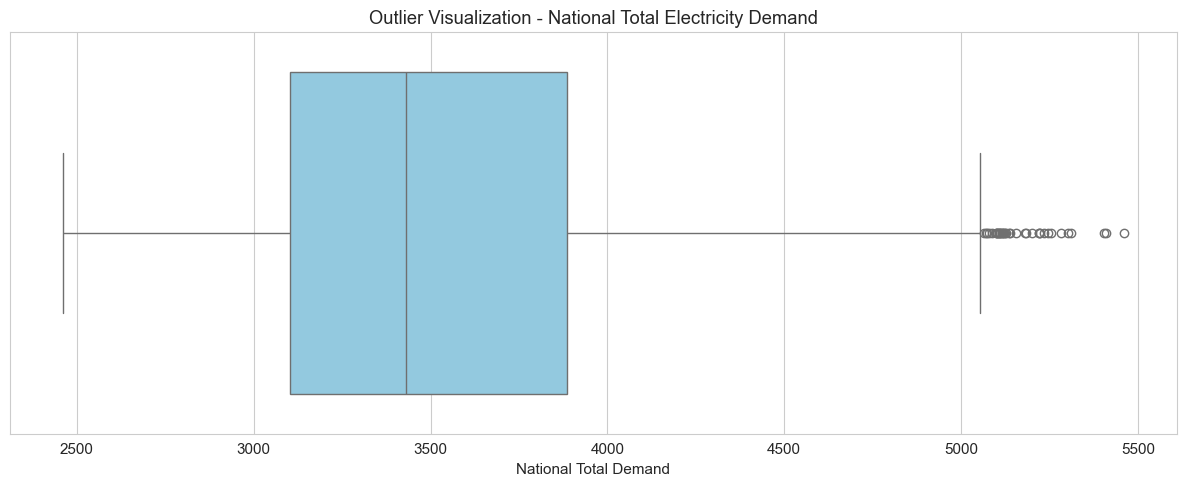

Outliers are not removed because demand spikes can represent real electricity behavior.


In [35]:
# ============================================================
# SECTION 8: OUTLIER DETECTION
# ============================================================

outlier_rows = []

for col in state_cols + [target_col]:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    iqr_outliers = df[
        (df[col] < lower) |
        (df[col] > upper)
    ].shape[0]

    if df[col].std() != 0:
        z_scores = np.abs((df[col] - df[col].mean()) / df[col].std())
        z_outliers = int((z_scores > 3).sum())
    else:
        z_outliers = 0

    outlier_rows.append({
        "Column": col,
        "IQR_Outliers": int(iqr_outliers),
        "ZScore_Outliers": z_outliers,
        "Lower_Bound": lower,
        "Upper_Bound": upper
    })

outlier_report = pd.DataFrame(outlier_rows)

display(outlier_report)

outlier_report.to_csv("energy_outlier_report.csv", index=False)

plt.figure(figsize=(12, 5))
sns.boxplot(x=df[target_col], color="skyblue")
plt.title("Outlier Visualization - National Total Electricity Demand")
plt.xlabel("National Total Demand")
plt.tight_layout()
plt.show()

print("Outliers are not removed because demand spikes can represent real electricity behavior.")

Dataset Shape: (3707, 38)

Data Types:


Dates                    datetime64[ns]
Andhra Pradesh                  float64
Arunachal Pradesh               float64
Assam                           float64
Bihar                           float64
Chandigarh                      float64
Chhattisgarh                    float64
DD                              float64
Delhi                           float64
DNH                             float64
DVC                             float64
Essar steel                     float64
Goa                             float64
Gujarat                         float64
Haryana                         float64
HP                              float64
J&K                             float64
Jharkhand                       float64
Karnataka                       float64
Kerala                          float64
Maharashtra                     float64
Manipur                         float64
Meghalaya                       float64
Mizoram                         float64
MP                              float64



Statistical Summary:


,Dates,Andhra Pradesh,Arunachal Pradesh,Assam,Bihar,Chandigarh,Chhattisgarh,DD,Delhi,DNH,...,Punjab,Rajasthan,Sikkim,Tamil Nadu,Telangana,Tripura,UP,Uttarakhand,West Bengal,National_Total_Demand
count,3707,3707.000000,3707.000000,3707.000000,3707.000000,3707.000000,3707.000000,3707.000000,3707.000000,3707.000000,...,3707.000000,3707.000000,3707.000000,3707.000000,3707.000000,3707.000000,3707.000000,3707.000000,3707.000000,3707.000000
mean,2019-03-04 02:41:59.125977856,177.242865,2.108336,27.313191,83.265929,4.582142,85.691233,10.574400,88.241786,17.368141,...,161.662773,224.408686,1.352711,298.492042,176.458349,3.953588,327.889156,37.868870,146.087240,3556.334233
min,2013-01-06 00:00:00,62.300000,0.600000,12.200000,20.900000,1.600000,37.200000,0.000000,41.800000,1.300000,...,56.100000,105.800000,0.300000,0.000000,97.200000,1.700000,178.300000,16.800000,51.500000,2460.500000
25%,2016-07-24 12:00:00,151.700000,1.900000,22.400000,63.900000,3.400000,73.300000,6.400000,65.000000,16.000000,...,110.000000,194.600000,1.100000,270.400000,141.400000,3.400000,265.300000,34.100000,120.100000,3102.950000
50%,2019-02-09 00:00:00,171.200000,2.100000,25.100000,77.500000,4.200000,82.700000,7.100000,84.700000,17.500000,...,141.200000,215.600000,1.300000,295.400000,168.700000,3.966667,301.500000,37.100000,142.400000,3430.900000
75%,2021-10-28 12:00:00,198.900000,2.300000,30.750000,100.300000,5.600000,95.700000,7.600000,107.950000,19.500000,...,205.850000,250.000000,1.500000,325.350000,205.350000,4.486002,377.300000,41.100000,164.900000,3886.250000
max,2024-09-29 00:00:00,266.400000,4.800000,55.800000,172.800000,9.100000,144.400000,28.000000,177.700000,20.700000,...,365.500000,379.100000,2.800000,443.600000,320.400000,9.500000,658.800000,74.300000,264.000000,5460.700000
std,NaN,34.391571,0.451194,6.841169,27.844169,1.326235,17.049535,8.106749,25.351894,2.691822,...,65.018687,45.853375,0.313589,43.143960,43.571213,0.794685,89.487251,6.033892,32.832482,589.680630


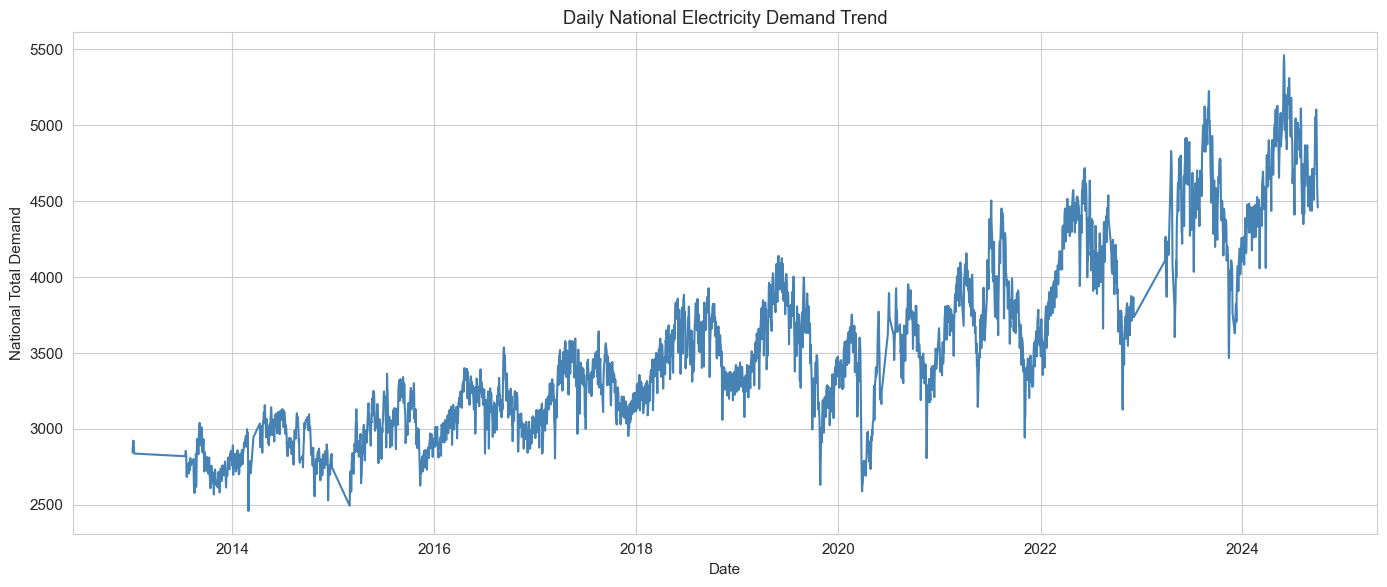

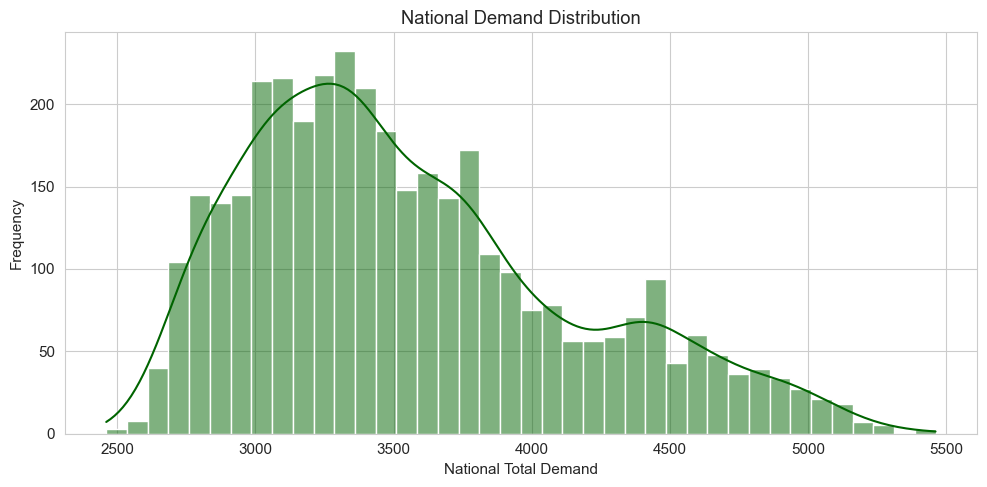

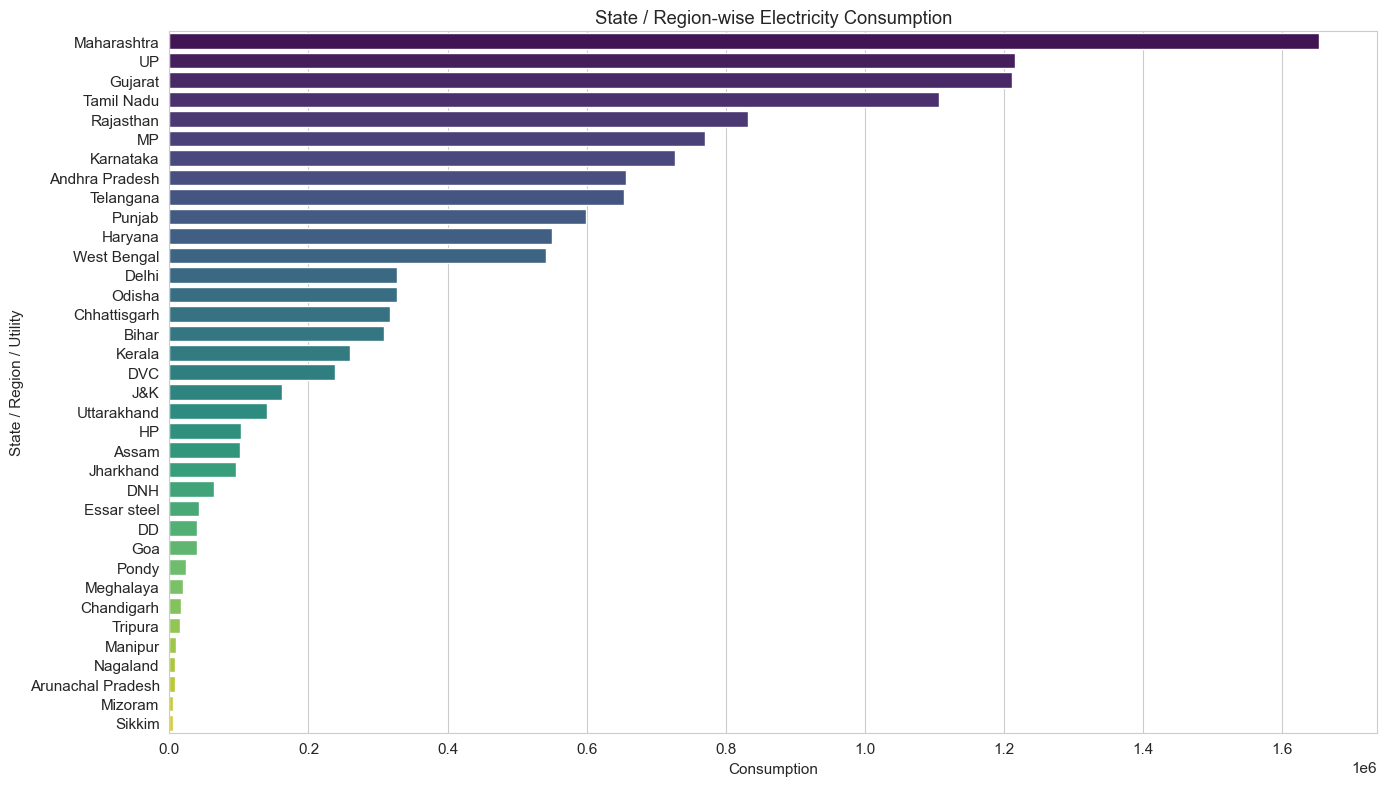

In [36]:
# ============================================================
# SECTION 9: BASIC EDA
# ============================================================

print("Dataset Shape:", df.shape)

print("\nData Types:")
display(df.dtypes)

print("\nStatistical Summary:")
display(df.describe())

plt.figure(figsize=(14, 6))
plt.plot(df[date_col], df[target_col], color="steelblue")
plt.title("Daily National Electricity Demand Trend")
plt.xlabel("Date")
plt.ylabel("National Total Demand")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.histplot(df[target_col], bins=40, kde=True, color="darkgreen")
plt.title("National Demand Distribution")
plt.xlabel("National Total Demand")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

region_consumption = df[state_cols].sum().sort_values(ascending=False)

plt.figure(figsize=(14, 8))
sns.barplot(x=region_consumption.values, y=region_consumption.index, palette="viridis")
plt.title("State / Region-wise Electricity Consumption")
plt.xlabel("Consumption")
plt.ylabel("State / Region / Utility")
plt.tight_layout()
plt.show()

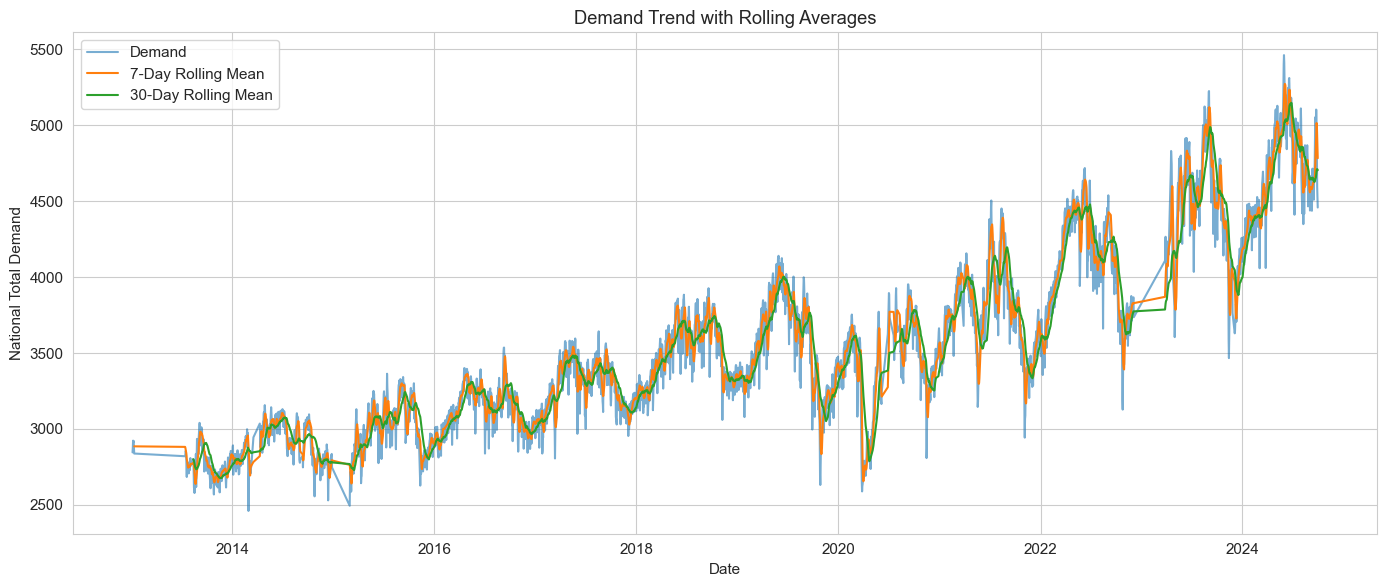

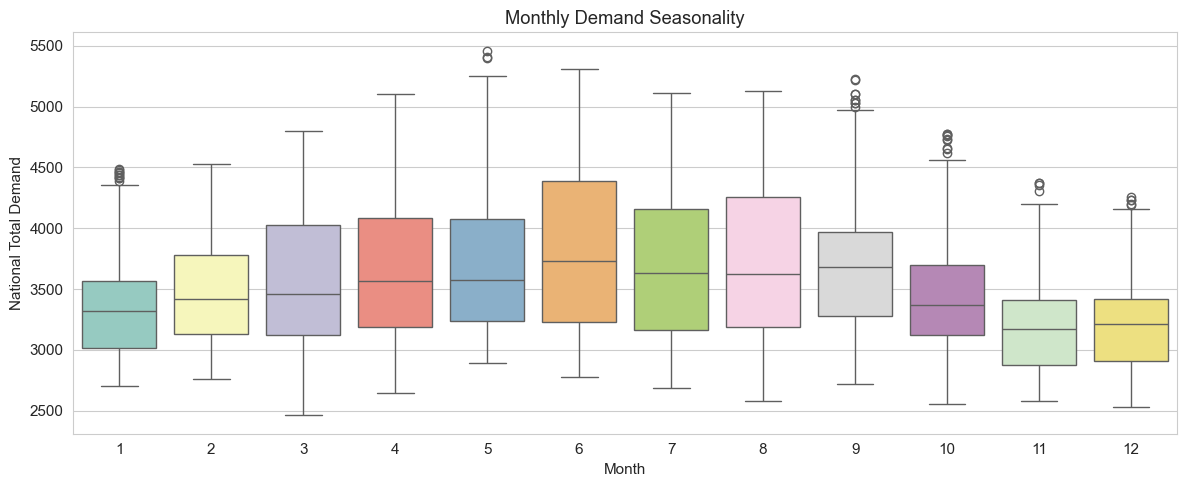

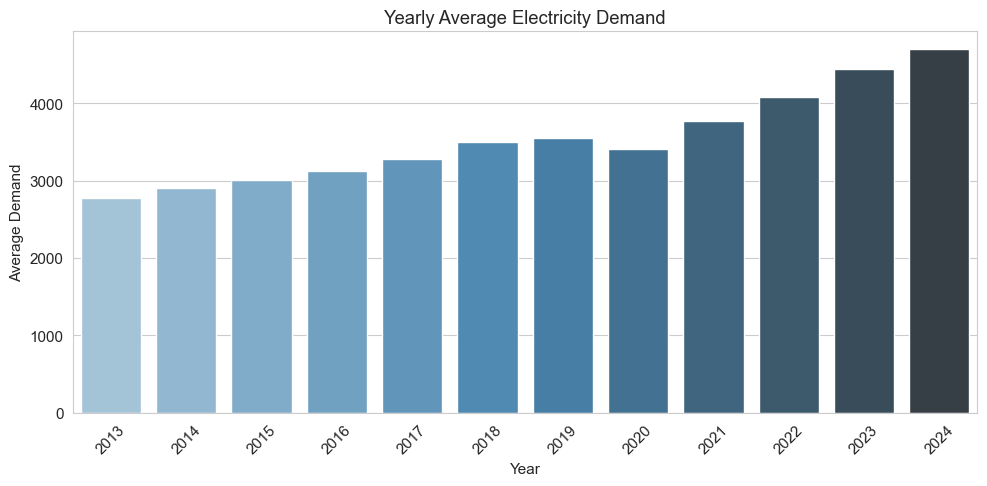

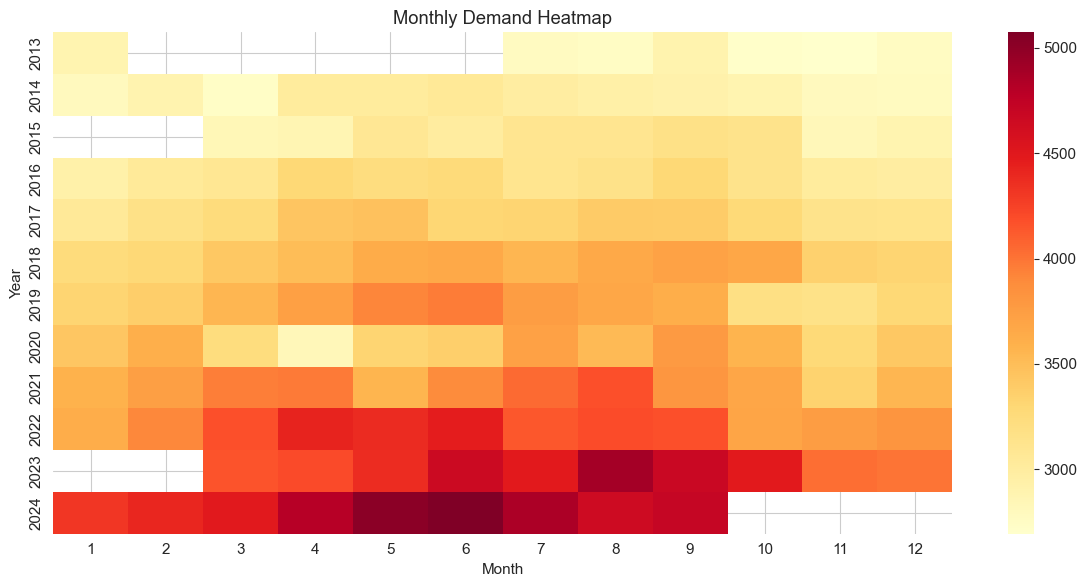

In [37]:
# ============================================================
# SECTION 10: ADVANCED EDA
# ============================================================

eda_df = df[[date_col, target_col]].copy()

eda_df["Year"] = eda_df[date_col].dt.year
eda_df["Month"] = eda_df[date_col].dt.month
eda_df["Day_of_Week"] = eda_df[date_col].dt.dayofweek
eda_df["Is_Weekend"] = eda_df["Day_of_Week"].isin([5, 6]).astype(int)
eda_df["RollingMean7"] = eda_df[target_col].rolling(7).mean()
eda_df["RollingMean30"] = eda_df[target_col].rolling(30).mean()
eda_df["RollingStd30"] = eda_df[target_col].rolling(30).std()
eda_df["Growth_Rate"] = eda_df[target_col].pct_change() * 100

yearly_demand = eda_df.groupby("Year")[target_col].mean().reset_index()

plt.figure(figsize=(14, 6))
plt.plot(eda_df[date_col], eda_df[target_col], label="Demand", alpha=0.6)
plt.plot(eda_df[date_col], eda_df["RollingMean7"], label="7-Day Rolling Mean")
plt.plot(eda_df[date_col], eda_df["RollingMean30"], label="30-Day Rolling Mean")
plt.title("Demand Trend with Rolling Averages")
plt.xlabel("Date")
plt.ylabel("National Total Demand")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
sns.boxplot(data=eda_df, x="Month", y=target_col, palette="Set3")
plt.title("Monthly Demand Seasonality")
plt.xlabel("Month")
plt.ylabel("National Total Demand")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(data=yearly_demand, x="Year", y=target_col, palette="Blues_d")
plt.title("Yearly Average Electricity Demand")
plt.xlabel("Year")
plt.ylabel("Average Demand")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

monthly_heatmap = eda_df.pivot_table(
    index="Year",
    columns="Month",
    values=target_col,
    aggfunc="mean"
)

plt.figure(figsize=(12, 6))
sns.heatmap(monthly_heatmap, cmap="YlOrRd", annot=False)
plt.title("Monthly Demand Heatmap")
plt.xlabel("Month")
plt.ylabel("Year")
plt.tight_layout()
plt.show()

In [38]:
# ============================================================
# SECTION 11: FEATURE ENGINEERING
# ============================================================

model_df = df[[date_col, target_col]].copy()

model_df["Year"] = model_df[date_col].dt.year
model_df["Month"] = model_df[date_col].dt.month
model_df["Quarter"] = model_df[date_col].dt.quarter
model_df["Week"] = model_df[date_col].dt.isocalendar().week.astype(int)
model_df["Day"] = model_df[date_col].dt.day
model_df["Day_of_Week"] = model_df[date_col].dt.dayofweek
model_df["Day_of_Year"] = model_df[date_col].dt.dayofyear
model_df["Is_Weekend"] = model_df["Day_of_Week"].isin([5, 6]).astype(int)

model_df["MonthSin"] = np.sin(2 * np.pi * model_df["Month"] / 12)
model_df["MonthCos"] = np.cos(2 * np.pi * model_df["Month"] / 12)
model_df["WeekSin"] = np.sin(2 * np.pi * model_df["Week"] / 52)
model_df["WeekCos"] = np.cos(2 * np.pi * model_df["Week"] / 52)
model_df["DayOfYearSin"] = np.sin(2 * np.pi * model_df["Day_of_Year"] / 365)
model_df["DayOfYearCos"] = np.cos(2 * np.pi * model_df["Day_of_Year"] / 365)

for lag in [1, 7, 14, 30, 60, 90]:
    model_df[f"Lag_{lag}"] = model_df[target_col].shift(lag)

for window in [7, 30, 90]:
    model_df[f"RollingMean{window}"] = model_df[target_col].shift(1).rolling(window).mean()
    model_df[f"RollingStd{window}"] = model_df[target_col].shift(1).rolling(window).std()

model_df["ExpandingMean"] = model_df[target_col].shift(1).expanding().mean()
model_df["Demand_Growth"] = model_df[target_col].pct_change()
model_df["Demand_Difference"] = model_df[target_col].diff()
model_df["DemandAcceleration"] = model_df["Demand_Difference"].diff()

model_df = model_df.replace([np.inf, -np.inf], np.nan)
model_df = model_df.dropna().reset_index(drop=True)

candidate_features = [
    col for col in model_df.columns
    if col not in [date_col, target_col]
]

print("Feature Count:", len(candidate_features))
print(candidate_features)

display(model_df.head())

Feature Count: 30
['Year', 'Month', 'Quarter', 'Week', 'Day', 'Day_of_Week', 'Day_of_Year', 'Is_Weekend', 'MonthSin', 'MonthCos', 'WeekSin', 'WeekCos', 'DayOfYearSin', 'DayOfYearCos', 'Lag_1', 'Lag_7', 'Lag_14', 'Lag_30', 'Lag_60', 'Lag_90', 'RollingMean7', 'RollingStd7', 'RollingMean30', 'RollingStd30', 'RollingMean90', 'RollingStd90', 'ExpandingMean', 'Demand_Growth', 'Demand_Difference', 'DemandAcceleration']


,Dates,National_Total_Demand,Year,Month,Quarter,Week,Day,Day_of_Week,Day_of_Year,Is_Weekend,...,RollingMean7,RollingStd7,RollingMean30,RollingStd30,RollingMean90,RollingStd90,ExpandingMean,Demand_Growth,Demand_Difference,DemandAcceleration
0,2013-10-23,2672.2,2013,10,4,43,23,2,296,0,...,2716.171429,28.083846,2771.156667,74.445985,2808.656667,106.995995,2808.656667,-0.014530,-39.4,-34.8
1,2013-10-24,2646.5,2013,10,4,43,24,3,297,0,...,2712.142857,32.412336,2764.173333,73.539461,2806.728889,107.880420,2807.157143,-0.009618,-25.7,13.7
2,2013-10-25,2667.2,2013,10,4,43,25,4,298,0,...,2701.500000,40.292679,2755.793333,72.084954,2804.171111,108.926684,2805.410870,0.007822,20.7,46.4
3,2013-10-26,2628.1,2013,10,4,43,26,5,299,1,...,2688.471429,32.892943,2746.890000,65.468352,2801.328889,109.128352,2803.924731,-0.014660,-39.1,-59.8
4,2013-10-27,2568.8,2013,10,4,43,27,6,300,1,...,2672.957143,31.951883,2737.160000,60.344086,2798.173333,109.991960,2802.054255,-0.022564,-59.3,-20.2


In [39]:
# ============================================================
# SECTION 12: FEATURE SELECTION
# ============================================================

X_all = model_df[candidate_features].copy()
y_all = model_df[target_col].copy()

mi_scores = mutual_info_regression(
    X_all,
    y_all,
    random_state=RANDOM_STATE
)

feature_ranking = pd.DataFrame({
    "Feature": candidate_features,
    "Mutual_Information": mi_scores
}).sort_values(by="Mutual_Information", ascending=False)

display(feature_ranking)

feature_ranking.to_csv("energy_feature_ranking.csv", index=False)

selected_features = feature_ranking.head(min(18, len(feature_ranking)))["Feature"].tolist()

pd.DataFrame({"Feature": selected_features}).to_csv("selected_features.csv", index=False)

print("Selected Features:")
print(selected_features)

,Feature,Mutual_Information
14,Lag_1,1.804846
20,RollingMean7,1.511859
26,ExpandingMean,1.421464
22,RollingMean30,1.303127
15,Lag_7,1.201903
24,RollingMean90,1.061594
16,Lag_14,1.036317
0,Year,0.906053
17,Lag_30,0.812098
18,Lag_60,0.605791


Selected Features:
['Lag_1', 'RollingMean7', 'ExpandingMean', 'RollingMean30', 'Lag_7', 'RollingMean90', 'Lag_14', 'Year', 'Lag_30', 'Lag_60', 'RollingStd90', 'Lag_90', 'RollingStd30', 'Day_of_Year', 'Week', 'DayOfYearCos', 'WeekCos', 'RollingStd7']


In [40]:
# ============================================================
# SECTION 13: DATA SPLITTING
# ============================================================

X = model_df[selected_features].copy()
y = model_df[target_col].copy()

n = len(model_df)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

X_train = X.iloc[:train_end]
y_train = y.iloc[:train_end]

X_val = X.iloc[train_end:val_end]
y_val = y.iloc[train_end:val_end]

X_test = X.iloc[val_end:]
y_test = y.iloc[val_end:]

X_train_full = pd.concat([X_train, X_val])
y_train_full = pd.concat([y_train, y_val])

tscv = TimeSeriesSplit(n_splits=N_SPLITS)

print("Train Shape:", X_train.shape)
print("Validation Shape:", X_val.shape)
print("Test Shape:", X_test.shape)

Train Shape: (2531, 18)
Validation Shape: (543, 18)
Test Shape: (543, 18)


In [41]:
# ============================================================
# SECTION 14: HYPERPARAMETER TUNING
# ============================================================

best_parameters = {}

rf_params = {
    "n_estimators": [100, 200],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

xgb_params = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5],
    "learning_rate": [0.03, 0.05],
    "subsample": [0.8, 1.0]
}

extra_params = {
    "n_estimators": [100, 200],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5]
}

rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    rf_params,
    cv=tscv,
    scoring="r2",
    n_jobs=-1
)
rf_grid.fit(X_train, y_train)

xgb_grid = GridSearchCV(
    XGBRegressor(
        objective="reg:squarederror",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    xgb_params,
    cv=tscv,
    scoring="r2",
    n_jobs=-1
)
xgb_grid.fit(X_train, y_train)

extra_grid = GridSearchCV(
    ExtraTreesRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    extra_params,
    cv=tscv,
    scoring="r2",
    n_jobs=-1
)
extra_grid.fit(X_train, y_train)

best_rf = rf_grid.best_estimator_
best_xgb = xgb_grid.best_estimator_
best_extra = extra_grid.best_estimator_

best_parameters["Random Forest"] = rf_grid.best_params_
best_parameters["XGBoost"] = xgb_grid.best_params_
best_parameters["Extra Trees"] = extra_grid.best_params_

if CATBOOST_AVAILABLE:
    best_cat = CatBoostRegressor(
        iterations=200,
        depth=6,
        learning_rate=0.05,
        random_seed=RANDOM_STATE,
        verbose=0
    )
    best_cat.fit(X_train, y_train)

    best_parameters["CatBoost"] = {
        "iterations": 200,
        "depth": 6,
        "learning_rate": 0.05
    }
else:
    best_cat = None

save_json(best_parameters, "best_parameters.json")

print("Best Parameters:")
display(best_parameters)

Best Parameters:


{'Random Forest': {'max_depth': 5,
  'min_samples_leaf': 2,
  'min_samples_split': 5,
  'n_estimators': 100},
 'XGBoost': {'learning_rate': 0.05,
  'max_depth': 3,
  'n_estimators': 100,
  'subsample': 1.0},
 'Extra Trees': {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 100}}

In [42]:
# ============================================================
# SECTION 15: MODEL BUILDING
# ============================================================

linear_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

models = {
    "Linear Regression": linear_model,
    "Random Forest": best_rf,
    "XGBoost": best_xgb,
    "Extra Trees": best_extra
}

if LIGHTGBM_AVAILABLE:
    models["LightGBM"] = LGBMRegressor(
        random_state=RANDOM_STATE,
        n_estimators=200,
        learning_rate=0.05
    )

if CATBOOST_AVAILABLE:
    models["CatBoost"] = best_cat

voting_model = VotingRegressor(
    estimators=[
        ("lr", linear_model),
        ("rf", best_rf),
        ("xgb", best_xgb)
    ],
    n_jobs=-1
)

stacking_model = StackingRegressor(
    estimators=[
        ("rf", best_rf),
        ("xgb", best_xgb),
        ("extra", best_extra)
    ],
    final_estimator=LinearRegression(),
    cv=5,
    n_jobs=-1
)

weighted_estimators = [
    ("xgb", best_xgb),
    ("rf", best_rf)
]

weighted_weights = [0.60, 0.40]

if CATBOOST_AVAILABLE:
    weighted_estimators = [
        ("xgb", best_xgb),
        ("cat", best_cat),
        ("rf", best_rf)
    ]
    weighted_weights = [0.40, 0.35, 0.25]

weighted_model = WeightedEnsembleRegressor(
    estimators=weighted_estimators,
    weights=weighted_weights
)

models["Voting Regressor"] = voting_model
models["Stacking Regressor"] = stacking_model
models["Weighted Ensemble"] = weighted_model

print("Models:")
print(list(models.keys()))

Models:
['Linear Regression', 'Random Forest', 'XGBoost', 'Extra Trees', 'LightGBM', 'Voting Regressor', 'Stacking Regressor', 'Weighted Ensemble']


In [43]:
# ============================================================
# SECTION 16: MODEL TRAINING AND EVALUATION
# ============================================================

results = []
trained_models = {}

for model_name, model in models.items():
    start_train = time.time()

    model.fit(X_train_full, y_train_full)

    training_time = time.time() - start_train

    start_pred = time.time()

    y_pred = model.predict(X_test)

    prediction_time = time.time() - start_pred

    train_pred = model.predict(X_train_full)

    train_r2 = r2_score(y_train_full, train_pred)
    test_r2 = r2_score(y_test, y_pred)

    metrics = regression_metrics(y_test, y_pred)

    try:
        cv_scores = cross_val_score(
            model,
            X_train_full,
            y_train_full,
            cv=tscv,
            scoring="r2",
            n_jobs=-1
        )
        cv_mean = cv_scores.mean()
        cv_std = cv_scores.std()
    except Exception:
        cv_mean = np.nan
        cv_std = np.nan

    results.append({
        "Model": model_name,
        "MAE": metrics["MAE"],
        "RMSE": metrics["RMSE"],
        "R2": metrics["R2"],
        "MAPE": metrics["MAPE"],
        "Median_AE": metrics["Median_AE"],
        "Explained_Variance": metrics["Explained_Variance"],
        "CV_Mean_R2": cv_mean,
        "CV_Std": cv_std,
        "Train_R2": train_r2,
        "Test_R2": test_r2,
        "Overfitting_Gap": train_r2 - test_r2,
        "Fit_Status": fit_status(train_r2, test_r2),
        "Training_Time": training_time,
        "Prediction_Time": prediction_time
    })

    trained_models[model_name] = model

results_df = pd.DataFrame(results)

ranking_df = results_df.sort_values(
    by=["RMSE", "MAPE", "R2", "CV_Mean_R2"],
    ascending=[True, True, False, False]
).reset_index(drop=True)

ranking_df["Rank"] = range(1, len(ranking_df) + 1)

display(ranking_df)

best_model_name = ranking_df.loc[0, "Model"]
best_model = trained_models[best_model_name]
best_row = ranking_df.loc[0]

hybrid_names = ["Voting Regressor", "Stacking Regressor", "Weighted Ensemble"]
hybrid_df = ranking_df[ranking_df["Model"].isin(hybrid_names)].copy()

if len(hybrid_df) > 0:
    best_hybrid_name = hybrid_df.iloc[0]["Model"]
    best_hybrid_model = trained_models[best_hybrid_name]
else:
    best_hybrid_name = None
    best_hybrid_model = None

print("Best Overall Model:", best_model_name)
print("Best Hybrid Model:", best_hybrid_name)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003110 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3917
[LightGBM] [Info] Number of data points in the train set: 3074, number of used features: 18
[LightGBM] [Info] Start training from score 3402.756930


,Model,MAE,RMSE,R2,MAPE,Median_AE,Explained_Variance,CV_Mean_R2,CV_Std,Train_R2,Test_R2,Overfitting_Gap,Fit_Status,Training_Time,Prediction_Time,Rank
0,Linear Regression,93.008118,119.003418,0.893516,2.051193,77.350416,0.897363,0.855069,0.069483,0.963199,0.893516,0.069682,Slight Overfitting,0.050796,0.008208,1
1,Stacking Regressor,153.289882,192.980639,0.719979,3.350163,125.482527,0.721771,0.715797,0.123904,0.948226,0.719979,0.228247,Severe Overfitting,10.674827,0.206104,2
2,Voting Regressor,153.905354,199.517404,0.700687,3.263323,115.568513,0.794683,0.762836,0.106901,0.966198,0.700687,0.265510,Severe Overfitting,1.745622,0.131292,3
3,Random Forest,177.736311,239.769249,0.567735,3.742371,123.157700,0.699627,0.712237,0.137288,0.966324,0.567735,0.398589,Severe Overfitting,2.037176,0.197761,4
4,Weighted Ensemble,199.501514,266.814274,0.464719,4.188548,140.458496,0.660095,0.652333,0.169839,0.966854,0.464719,0.502135,Underfitting,2.180384,0.115261,5
5,LightGBM,199.811743,267.048883,0.463778,4.197779,136.225627,0.642928,0.556150,0.246445,0.986682,0.463778,0.522904,Underfitting,4.709678,0.008211,6
6,XGBoost,215.943099,286.436693,0.383091,4.530136,158.726172,0.627697,0.584067,0.217721,0.966511,0.383091,0.583420,Underfitting,3.233033,0.033065,7
7,Extra Trees,225.560233,296.091268,0.340804,4.734802,171.548035,0.620506,0.577355,0.231990,0.959326,0.340804,0.618522,Underfitting,0.493329,0.231070,8


Best Overall Model: Linear Regression
Best Hybrid Model: Stacking Regressor


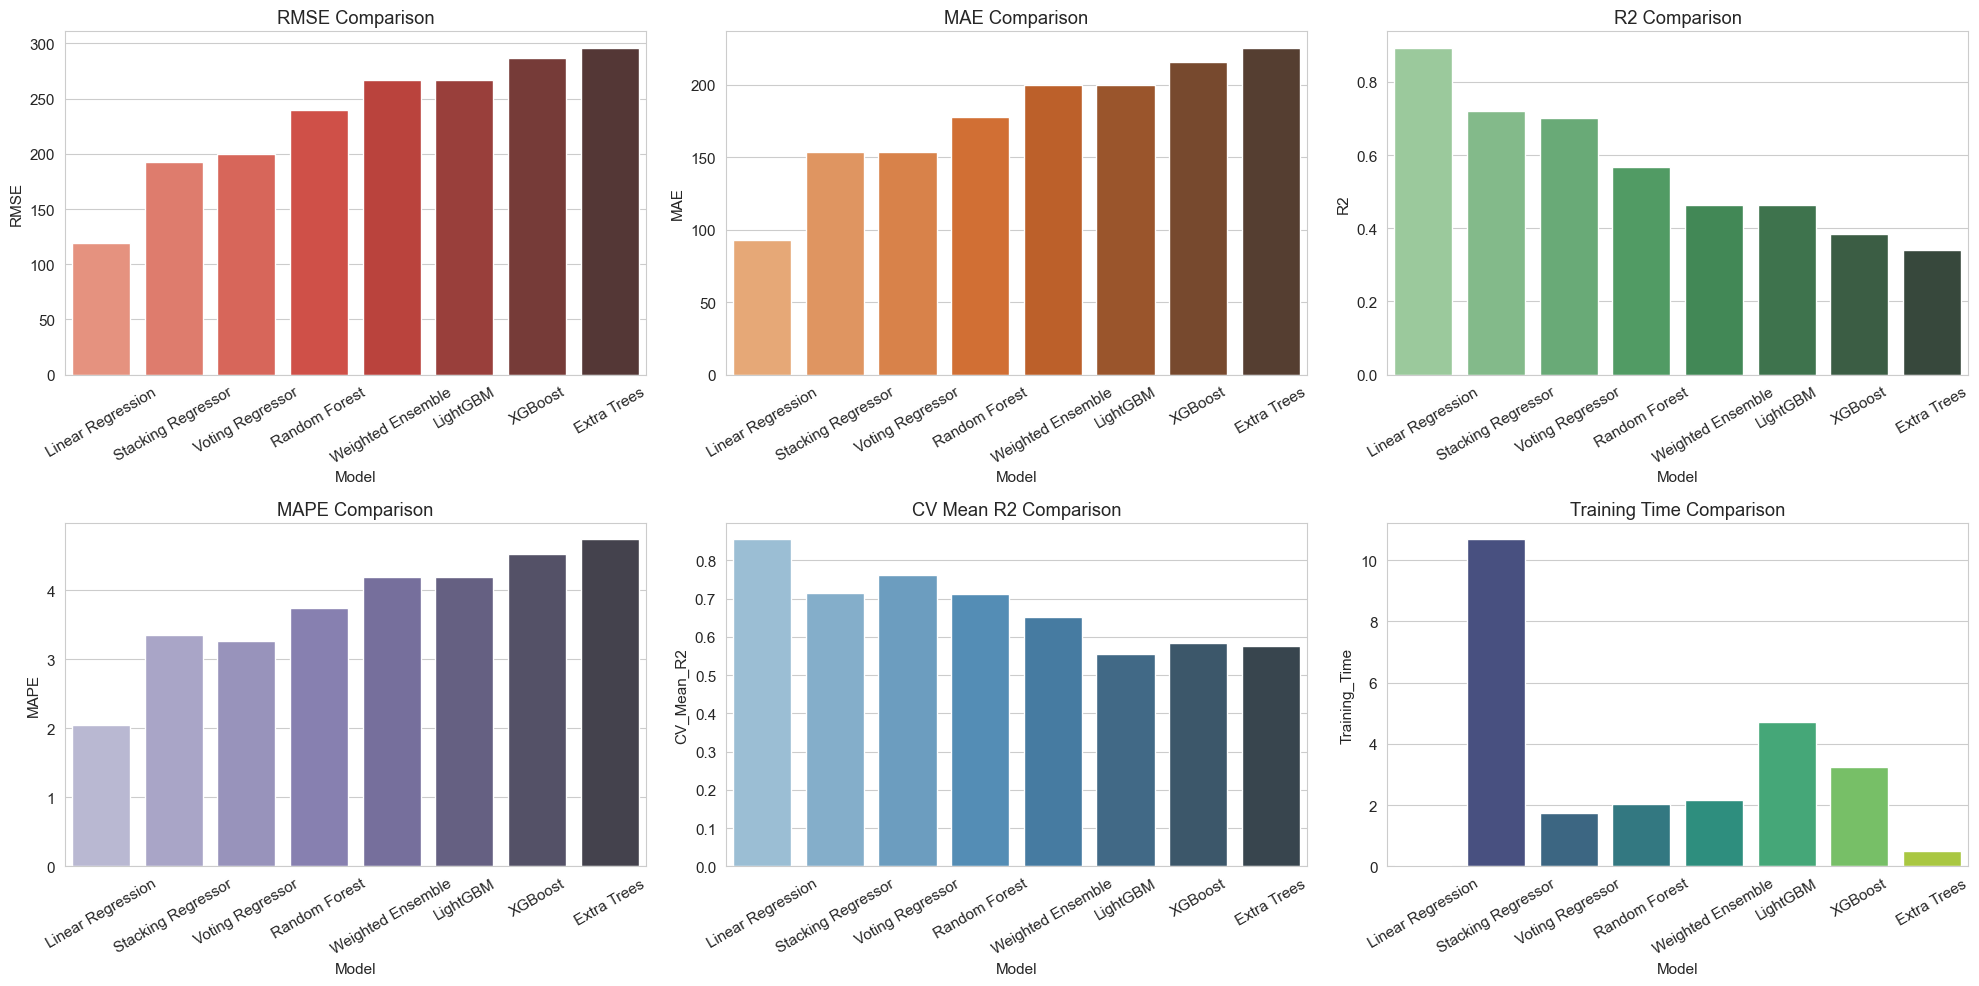

In [44]:
# ============================================================
# SECTION 17: MODEL COMPARISON VISUALIZATION
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(20, 10))

sns.barplot(data=ranking_df, x="Model", y="RMSE", ax=axes[0, 0], palette="Reds_d")
axes[0, 0].set_title("RMSE Comparison")
axes[0, 0].tick_params(axis="x", rotation=30)

sns.barplot(data=ranking_df, x="Model", y="MAE", ax=axes[0, 1], palette="Oranges_d")
axes[0, 1].set_title("MAE Comparison")
axes[0, 1].tick_params(axis="x", rotation=30)

sns.barplot(data=ranking_df, x="Model", y="R2", ax=axes[0, 2], palette="Greens_d")
axes[0, 2].set_title("R2 Comparison")
axes[0, 2].tick_params(axis="x", rotation=30)

sns.barplot(data=ranking_df, x="Model", y="MAPE", ax=axes[1, 0], palette="Purples_d")
axes[1, 0].set_title("MAPE Comparison")
axes[1, 0].tick_params(axis="x", rotation=30)

sns.barplot(data=ranking_df, x="Model", y="CV_Mean_R2", ax=axes[1, 1], palette="Blues_d")
axes[1, 1].set_title("CV Mean R2 Comparison")
axes[1, 1].tick_params(axis="x", rotation=30)

sns.barplot(data=ranking_df, x="Model", y="Training_Time", ax=axes[1, 2], palette="viridis")
axes[1, 2].set_title("Training Time Comparison")
axes[1, 2].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("energy_model_comparison.png", dpi=300)
plt.show()

,Model,Train_R2,Test_R2,CV_Mean_R2,Overfitting_Gap,Fit_Status
0,Linear Regression,0.963199,0.893516,0.855069,0.069682,Slight Overfitting
1,Stacking Regressor,0.948226,0.719979,0.715797,0.228247,Severe Overfitting
2,Voting Regressor,0.966198,0.700687,0.762836,0.265510,Severe Overfitting
3,Random Forest,0.966324,0.567735,0.712237,0.398589,Severe Overfitting
4,Weighted Ensemble,0.966854,0.464719,0.652333,0.502135,Underfitting
5,LightGBM,0.986682,0.463778,0.556150,0.522904,Underfitting
6,XGBoost,0.966511,0.383091,0.584067,0.583420,Underfitting
7,Extra Trees,0.959326,0.340804,0.577355,0.618522,Underfitting


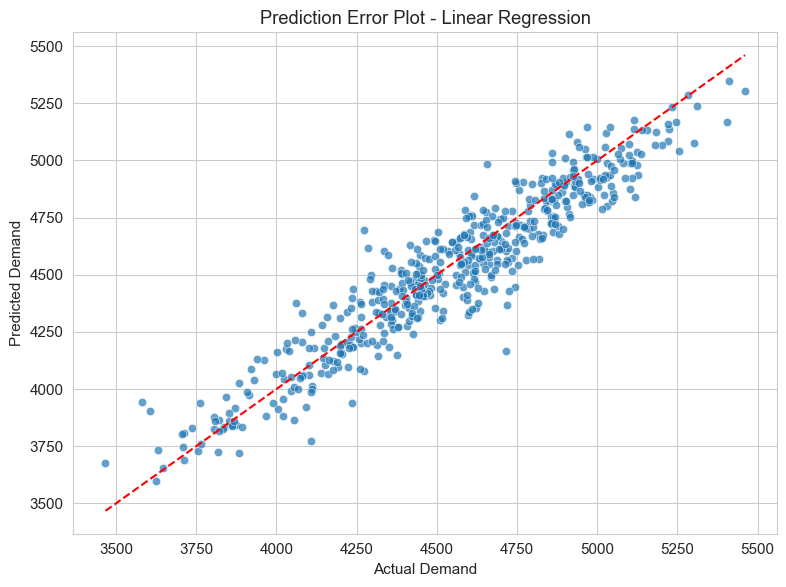

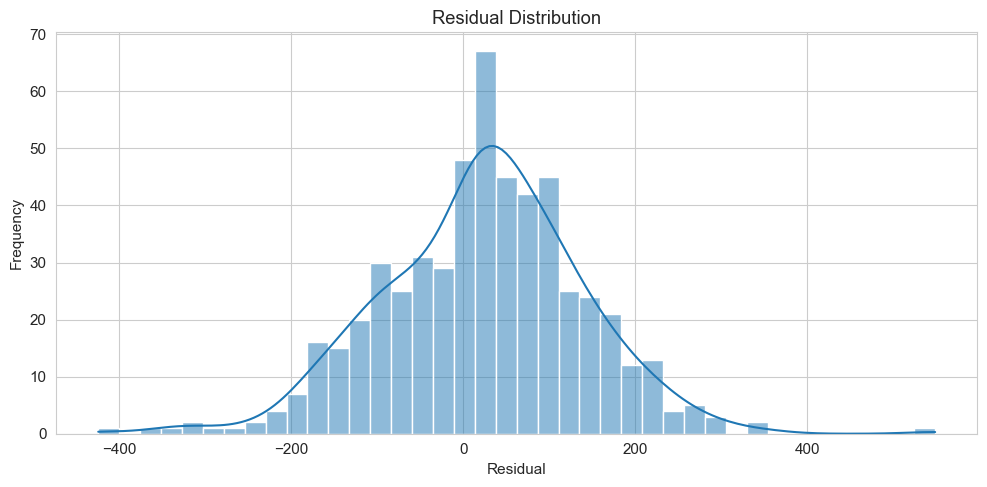

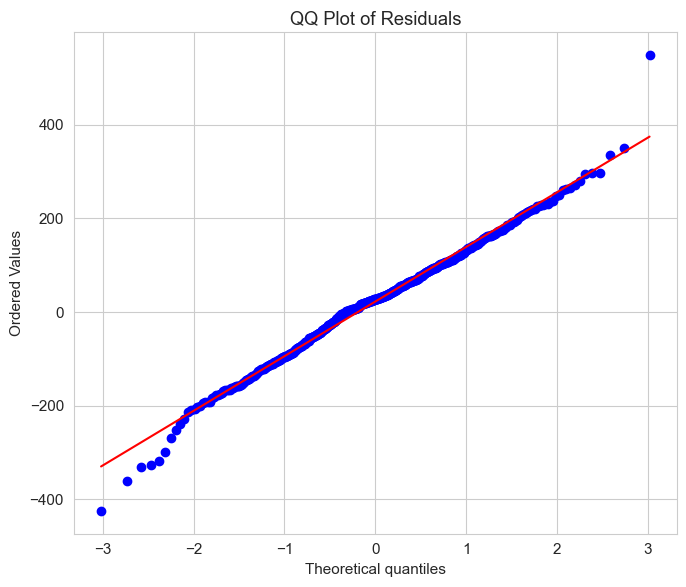

In [45]:
# ============================================================
# SECTION 18: OVERFITTING ANALYSIS
# ============================================================

overfitting_report = ranking_df[
    [
        "Model",
        "Train_R2",
        "Test_R2",
        "CV_Mean_R2",
        "Overfitting_Gap",
        "Fit_Status"
    ]
].copy()

display(overfitting_report)

overfitting_report.to_csv("overfitting_report.csv", index=False)

best_pred = best_model.predict(X_test)
residuals = y_test - best_pred

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=best_pred, alpha=0.7)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--"
)
plt.title(f"Prediction Error Plot - {best_model_name}")
plt.xlabel("Actual Demand")
plt.ylabel("Predicted Demand")
plt.tight_layout()
plt.savefig("energy_prediction_error_plot.png", dpi=300)
plt.show()

plt.figure(figsize=(10, 5))
sns.histplot(residuals, bins=40, kde=True)
plt.title("Residual Distribution")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("energy_residual_plot.png", dpi=300)
plt.show()

if SCIPY_AVAILABLE:
    plt.figure(figsize=(7, 6))
    stats.probplot(residuals, dist="norm", plot=plt)
    plt.title("QQ Plot of Residuals")
    plt.tight_layout()
    plt.savefig("energy_qq_plot.png", dpi=300)
    plt.show()

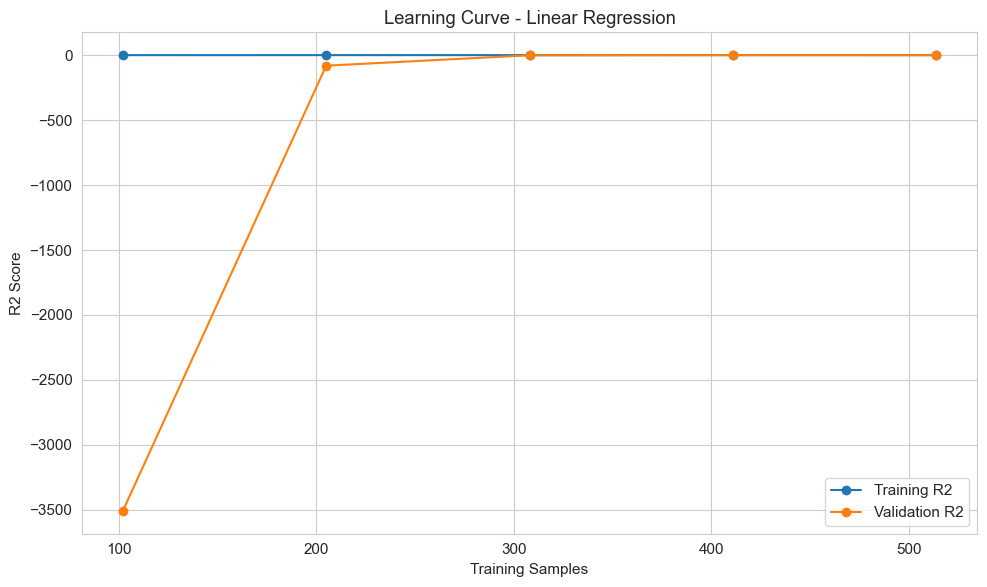

In [46]:
# ============================================================
# SECTION 19: LEARNING CURVE
# ============================================================

if ENABLE_LEARNING_CURVE:
    train_sizes, train_scores, val_scores = learning_curve(
        best_model,
        X_train_full,
        y_train_full,
        cv=tscv,
        scoring="r2",
        n_jobs=-1,
        train_sizes=np.linspace(0.2, 1.0, 5)
    )

    plt.figure(figsize=(10, 6))
    plt.plot(train_sizes, train_scores.mean(axis=1), marker="o", label="Training R2")
    plt.plot(train_sizes, val_scores.mean(axis=1), marker="o", label="Validation R2")
    plt.title(f"Learning Curve - {best_model_name}")
    plt.xlabel("Training Samples")
    plt.ylabel("R2 Score")
    plt.legend()
    plt.tight_layout()
    plt.savefig("energy_learning_curve.png", dpi=300)
    plt.show()

,Feature,Importance
0,Lag_1,1.426687
3,RollingMean30,0.037902
4,Lag_7,0.034371
6,Lag_14,0.032634
15,DayOfYearCos,0.017350
16,WeekCos,0.006024
7,Year,0.003486
5,RollingMean90,0.001392
2,ExpandingMean,0.001387
11,Lag_90,0.000706


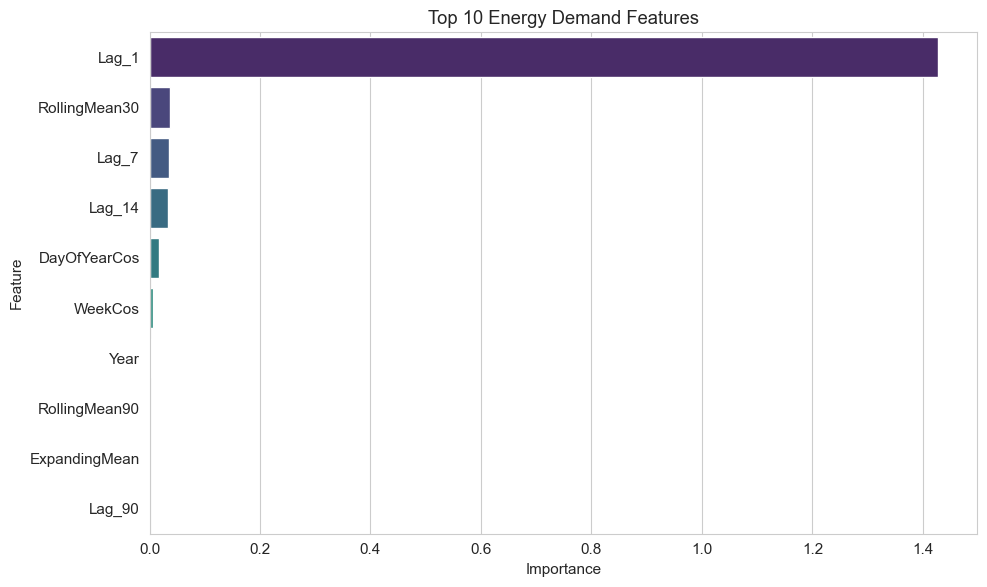

In [47]:
# ============================================================
# SECTION 20: FEATURE IMPORTANCE
# ============================================================

importance_df = pd.DataFrame()

if hasattr(best_model, "feature_importances_"):
    importance_df = pd.DataFrame({
        "Feature": selected_features,
        "Importance": best_model.feature_importances_
    }).sort_values(by="Importance", ascending=False)

else:
    try:
        perm = permutation_importance(
            best_model,
            X_test,
            y_test,
            n_repeats=10,
            random_state=RANDOM_STATE,
            n_jobs=-1
        )

        importance_df = pd.DataFrame({
            "Feature": selected_features,
            "Importance": perm.importances_mean
        }).sort_values(by="Importance", ascending=False)

    except Exception:
        importance_df = feature_ranking.rename(
            columns={"Mutual_Information": "Importance"}
        )[["Feature", "Importance"]]

display(importance_df)

importance_df.to_csv("feature_importance.csv", index=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=importance_df.head(10),
    x="Importance",
    y="Feature",
    palette="viridis"
)
plt.title("Top 10 Energy Demand Features")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("energy_feature_importance.png", dpi=300)
plt.show()

In [48]:
# ============================================================
# SECTION 21: SHAP EXPLAINABILITY
# ============================================================

if ENABLE_SHAP and SHAP_AVAILABLE:
    try:
        shap_sample = X_test.sample(
            n=min(300, len(X_test)),
            random_state=RANDOM_STATE
        )

        if best_model_name in ["XGBoost", "Random Forest", "Extra Trees", "LightGBM", "CatBoost"]:
            explainer = shap.Explainer(best_model, shap_sample)
            shap_values = explainer(shap_sample)

            shap_importance = pd.DataFrame({
                "Feature": shap_sample.columns,
                "Mean_Abs_SHAP": np.abs(shap_values.values).mean(axis=0)
            }).sort_values(by="Mean_Abs_SHAP", ascending=False)

            display(shap_importance)

            shap_importance.to_csv("energy_shap_importance.csv", index=False)

            shap.summary_plot(shap_values, shap_sample, show=True)

        else:
            shap_importance = pd.DataFrame(columns=["Feature", "Mean_Abs_SHAP"])
            shap_importance.to_csv("energy_shap_importance.csv", index=False)
            print("SHAP skipped because best model is hybrid or pipeline.")

    except Exception as e:
        shap_importance = pd.DataFrame(columns=["Feature", "Mean_Abs_SHAP"])
        shap_importance.to_csv("energy_shap_importance.csv", index=False)
        print("SHAP skipped due to error:", e)

else:
    shap_importance = pd.DataFrame(columns=["Feature", "Mean_Abs_SHAP"])
    shap_importance.to_csv("energy_shap_importance.csv", index=False)

SHAP skipped because best model is hybrid or pipeline.


,Date,Predicted_Demand,Lower_95_CI,Upper_95_CI
0,2024-09-30,4516.973898,4283.727200,4750.220596
1,2024-10-01,4561.806613,4328.559914,4795.053311
2,2024-10-02,4584.222442,4350.975744,4817.469140
3,2024-10-03,4584.835885,4351.589187,4818.082584
4,2024-10-04,4578.892324,4345.645626,4812.139022


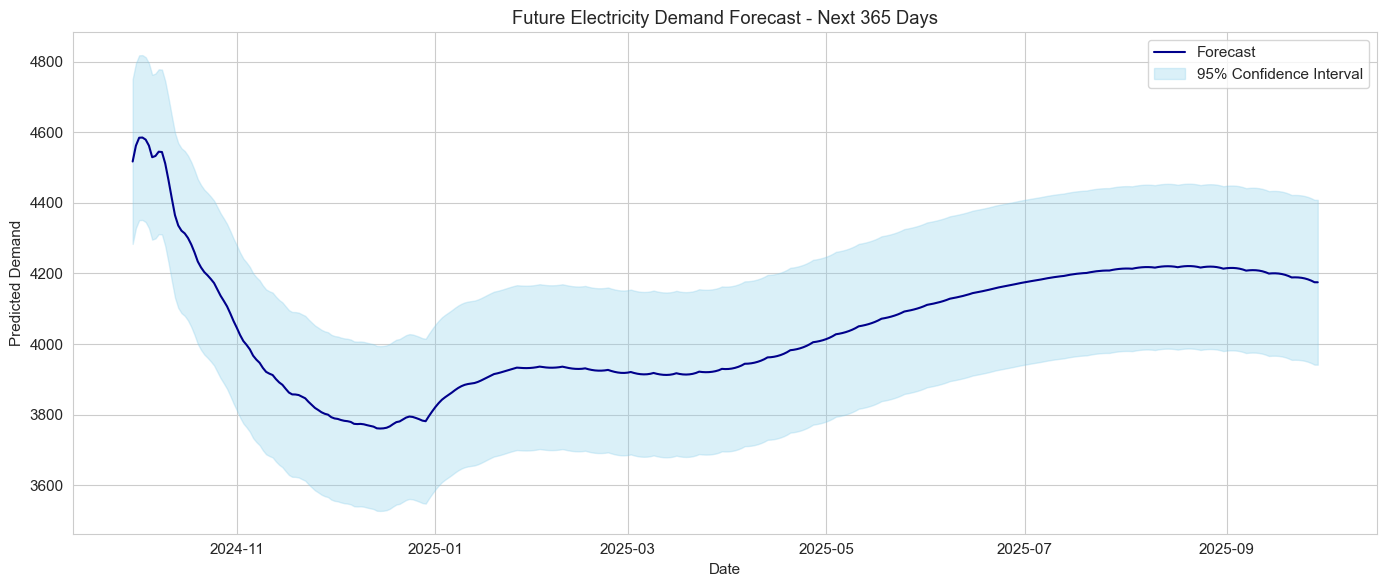

In [49]:
# ============================================================
# SECTION 22: FUTURE FORECASTING
# ============================================================

def create_next_feature_row(history_df, next_date):
    temp = {}

    temp["Year"] = next_date.year
    temp["Month"] = next_date.month
    temp["Quarter"] = pd.Timestamp(next_date).quarter
    temp["Week"] = int(pd.Timestamp(next_date).isocalendar().week)
    temp["Day"] = next_date.day
    temp["Day_of_Week"] = next_date.dayofweek
    temp["Day_of_Year"] = next_date.dayofyear
    temp["Is_Weekend"] = int(next_date.dayofweek in [5, 6])

    temp["MonthSin"] = np.sin(2 * np.pi * temp["Month"] / 12)
    temp["MonthCos"] = np.cos(2 * np.pi * temp["Month"] / 12)
    temp["WeekSin"] = np.sin(2 * np.pi * temp["Week"] / 52)
    temp["WeekCos"] = np.cos(2 * np.pi * temp["Week"] / 52)
    temp["DayOfYearSin"] = np.sin(2 * np.pi * temp["Day_of_Year"] / 365)
    temp["DayOfYearCos"] = np.cos(2 * np.pi * temp["Day_of_Year"] / 365)

    demand_series = history_df[target_col]

    for lag in [1, 7, 14, 30, 60, 90]:
        temp[f"Lag_{lag}"] = demand_series.iloc[-lag] if len(demand_series) >= lag else demand_series.iloc[-1]

    for window in [7, 30, 90]:
        temp[f"RollingMean{window}"] = demand_series.tail(window).mean()
        temp[f"RollingStd{window}"] = demand_series.tail(window).std()

    temp["ExpandingMean"] = demand_series.expanding().mean().iloc[-1]
    temp["Demand_Growth"] = demand_series.pct_change().iloc[-1]
    temp["Demand_Difference"] = demand_series.diff().iloc[-1]
    temp["DemandAcceleration"] = demand_series.diff().diff().iloc[-1]

    row = pd.DataFrame([temp])

    for feature in selected_features:
        if feature not in row.columns:
            row[feature] = X[feature].median()

    row = row[selected_features].replace([np.inf, -np.inf], np.nan).fillna(0)

    return row


def forecast_future_demand(days=365):
    history = model_df[[date_col, target_col]].copy()
    forecasts = []

    last_date = history[date_col].iloc[-1]

    test_rmse = float(best_row["RMSE"])

    for i in range(1, days + 1):
        next_date = last_date + pd.Timedelta(days=i)

        next_features = create_next_feature_row(history, next_date)

        prediction = float(best_model.predict(next_features)[0])

        lower_ci = prediction - 1.96 * test_rmse
        upper_ci = prediction + 1.96 * test_rmse

        forecasts.append({
            "Date": next_date,
            "Predicted_Demand": prediction,
            "Lower_95_CI": lower_ci,
            "Upper_95_CI": upper_ci
        })

        history = pd.concat([
            history,
            pd.DataFrame({
                date_col: [next_date],
                target_col: [prediction]
            })
        ], ignore_index=True)

    return pd.DataFrame(forecasts)


future_forecast_df = forecast_future_demand(days=365)

future_forecast_df.to_csv("future_energy_forecast.csv", index=False)

display(future_forecast_df.head())

plt.figure(figsize=(14, 6))
plt.plot(
    future_forecast_df["Date"],
    future_forecast_df["Predicted_Demand"],
    label="Forecast",
    color="darkblue"
)
plt.fill_between(
    future_forecast_df["Date"],
    future_forecast_df["Lower_95_CI"],
    future_forecast_df["Upper_95_CI"],
    color="skyblue",
    alpha=0.3,
    label="95% Confidence Interval"
)
plt.title("Future Electricity Demand Forecast - Next 365 Days")
plt.xlabel("Date")
plt.ylabel("Predicted Demand")
plt.legend()
plt.tight_layout()
plt.savefig("energy_future_forecast.png", dpi=300)
plt.show()

In [50]:
# ============================================================
# SECTION 23: ENERGY DEMAND AGENT FUNCTION
# ============================================================

def predict_future_demand(days=1):
    return forecast_future_demand(days=days)


def energy_demand_agent(days=1, renewable_generation_available=None):
    forecast = predict_future_demand(days=days)

    predicted_demand = float(forecast["Predicted_Demand"].iloc[-1])

    confidence_score = get_confidence_score(best_row)

    if renewable_generation_available is None:
        renewable_generation_available = predicted_demand * 0.85

    expected_demand_gap = predicted_demand - renewable_generation_available

    if expected_demand_gap <= 0:
        risk_level = "Low"
        recommended_action = "Renewable Generation Sufficient"
    elif expected_demand_gap <= predicted_demand * 0.10:
        risk_level = "Medium"
        recommended_action = "Increase Renewable Generation"
    else:
        risk_level = "High"
        recommended_action = "Activate Demand Response and Increase Renewable Dispatch"

    return {
        "agent": "energy_demand",
        "predicted_demand": predicted_demand,
        "forecast_days": days,
        "confidence_score": confidence_score,
        "renewable_generation_required": predicted_demand,
        "renewable_generation_available": float(renewable_generation_available),
        "expected_demand_gap": float(expected_demand_gap),
        "risk_level": risk_level,
        "recommended_action": recommended_action,
        "best_model": best_model_name,
        "timestamp": str(pd.Timestamp.now()),
        "status": "success"
    }


energy_agent_output = energy_demand_agent(days=1)

display(energy_agent_output)

{'agent': 'energy_demand',
 'predicted_demand': 4516.973898108861,
 'forecast_days': 1,
 'confidence_score': 0.8550692218106747,
 'renewable_generation_required': 4516.973898108861,
 'renewable_generation_available': 3839.427813392532,
 'expected_demand_gap': 677.5460847163295,
 'risk_level': 'High',
 'recommended_action': 'Activate Demand Response and Increase Renewable Dispatch',
 'best_model': 'Linear Regression',
 'timestamp': '2026-07-11 13:38:39.904175',
 'status': 'success'}

,agent,predicted_demand,forecast_days,confidence_score,renewable_generation_required,renewable_generation_available,expected_demand_gap,risk_level,recommended_action,best_model,timestamp,status,Scenario
0,energy_demand,4516.973898,1,0.855069,4516.973898,3839.427813,677.546085,High,Activate Demand Response and Increase Renewabl...,Linear Regression,2026-07-11 13:38:39.987017,success,Next Day Normal Demand
1,energy_demand,4106.818673,30,0.855069,4106.818673,3490.795872,616.022801,High,Activate Demand Response and Increase Renewabl...,Linear Regression,2026-07-11 13:38:40.473858,success,Next 30 Days Demand
2,energy_demand,3783.557317,90,0.855069,3783.557317,3216.023719,567.533598,High,Activate Demand Response and Increase Renewabl...,Linear Regression,2026-07-11 13:38:41.891596,success,Next 90 Days Demand
3,energy_demand,3923.494977,180,0.855069,3923.494977,3334.970731,588.524247,High,Activate Demand Response and Increase Renewabl...,Linear Regression,2026-07-11 13:38:44.671713,success,Next 180 Days Demand
4,energy_demand,4175.177755,365,0.855069,4175.177755,3548.901091,626.276663,High,Activate Demand Response and Increase Renewabl...,Linear Regression,2026-07-11 13:38:49.546735,success,Next 365 Days Demand
5,energy_demand,4516.973898,1,0.855069,4516.973898,2821.866000,1695.107898,High,Activate Demand Response and Increase Renewabl...,Linear Regression,2026-07-11 13:38:49.571808,success,Sudden Demand Spike
6,energy_demand,4516.973898,1,0.855069,4516.973898,5643.732000,-1126.758102,Low,Renewable Generation Sufficient,Linear Regression,2026-07-11 13:38:49.588289,success,Demand Drop Scenario
7,energy_demand,4516.973898,1,0.855069,4516.973898,3839.427813,677.546085,High,Activate Demand Response and Increase Renewabl...,Linear Regression,2026-07-11 13:38:49.596545,success,Missing Data Scenario


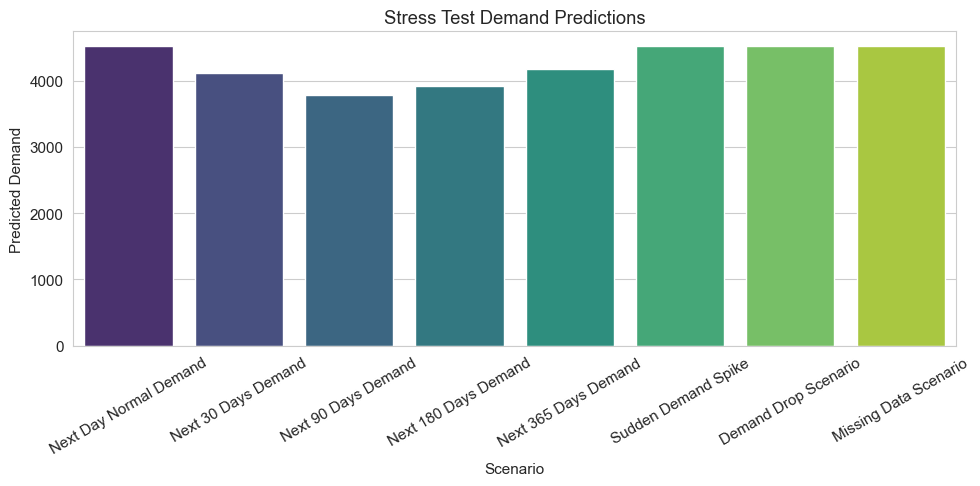

In [51]:
# ============================================================
# SECTION 24: STRESS TESTING
# ============================================================

stress_results = []

scenarios = [
    ("Next Day Normal Demand", 1, None),
    ("Next 30 Days Demand", 30, None),
    ("Next 90 Days Demand", 90, None),
    ("Next 180 Days Demand", 180, None),
    ("Next 365 Days Demand", 365, None),
    ("Sudden Demand Spike", 1, model_df[target_col].tail(30).mean() * 0.60),
    ("Demand Drop Scenario", 1, model_df[target_col].tail(30).mean() * 1.20),
    ("Missing Data Scenario", 1, None)
]

for scenario_name, days, renewable_available in scenarios:
    result = energy_demand_agent(
        days=days,
        renewable_generation_available=renewable_available
    )

    result["Scenario"] = scenario_name

    stress_results.append(result)

stress_test_df = pd.DataFrame(stress_results)

display(stress_test_df)

stress_test_df.to_csv("energy_stress_test_results.csv", index=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=stress_test_df, x="Scenario", y="predicted_demand", palette="viridis")
plt.title("Stress Test Demand Predictions")
plt.xlabel("Scenario")
plt.ylabel("Predicted Demand")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("energy_stress_test_distribution.png", dpi=300)
plt.show()

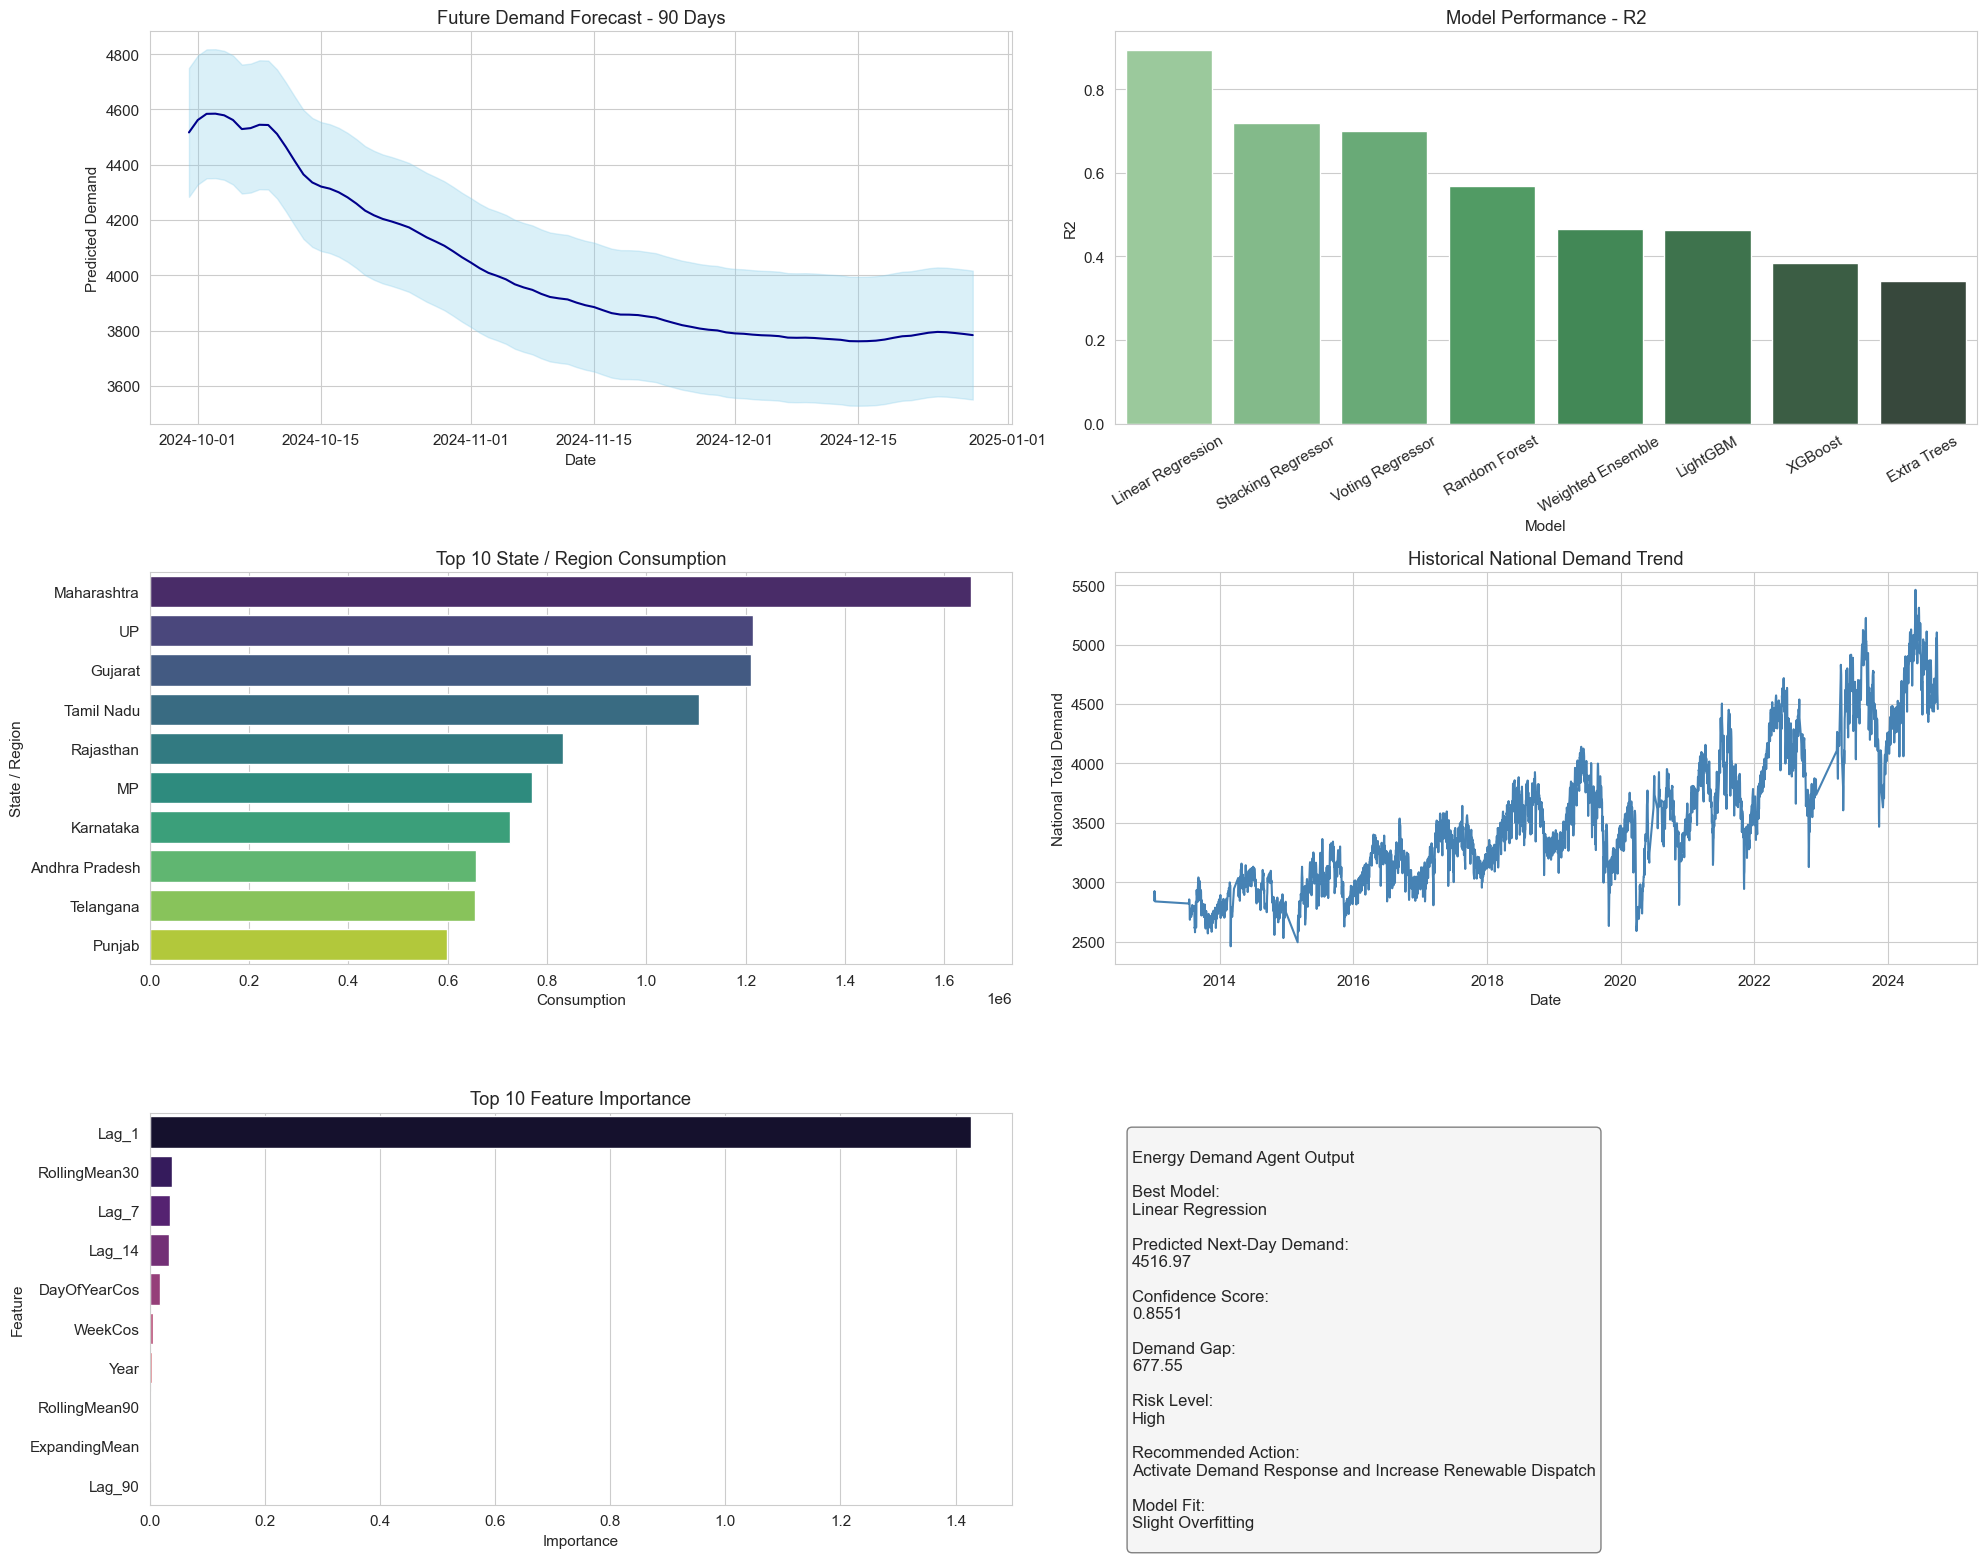

In [52]:
# ============================================================
# SECTION 25: EXECUTIVE DASHBOARD
# ============================================================

fig, axes = plt.subplots(3, 2, figsize=(20, 16))

axes[0, 0].plot(
    future_forecast_df["Date"].head(90),
    future_forecast_df["Predicted_Demand"].head(90),
    color="darkblue"
)
axes[0, 0].fill_between(
    future_forecast_df["Date"].head(90),
    future_forecast_df["Lower_95_CI"].head(90),
    future_forecast_df["Upper_95_CI"].head(90),
    color="skyblue",
    alpha=0.3
)
axes[0, 0].set_title("Future Demand Forecast - 90 Days")
axes[0, 0].set_xlabel("Date")
axes[0, 0].set_ylabel("Predicted Demand")

sns.barplot(
    data=ranking_df.head(8),
    x="Model",
    y="R2",
    ax=axes[0, 1],
    palette="Greens_d"
)
axes[0, 1].set_title("Model Performance - R2")
axes[0, 1].tick_params(axis="x", rotation=30)

top_regions = region_consumption.head(10)

sns.barplot(
    x=top_regions.values,
    y=top_regions.index,
    ax=axes[1, 0],
    palette="viridis"
)
axes[1, 0].set_title("Top 10 State / Region Consumption")
axes[1, 0].set_xlabel("Consumption")
axes[1, 0].set_ylabel("State / Region")

axes[1, 1].plot(df[date_col], df[target_col], color="steelblue")
axes[1, 1].set_title("Historical National Demand Trend")
axes[1, 1].set_xlabel("Date")
axes[1, 1].set_ylabel("National Total Demand")

sns.barplot(
    data=importance_df.head(10),
    x="Importance",
    y="Feature",
    ax=axes[2, 0],
    palette="magma"
)
axes[2, 0].set_title("Top 10 Feature Importance")

dashboard_text = f"""
Energy Demand Agent Output

Best Model:
{best_model_name}

Predicted Next-Day Demand:
{energy_agent_output["predicted_demand"]:.2f}

Confidence Score:
{energy_agent_output["confidence_score"]:.4f}

Demand Gap:
{energy_agent_output["expected_demand_gap"]:.2f}

Risk Level:
{energy_agent_output["risk_level"]}

Recommended Action:
{energy_agent_output["recommended_action"]}

Model Fit:
{ranking_df.loc[0, "Fit_Status"]}
"""

axes[2, 1].axis("off")
axes[2, 1].text(
    0.02,
    0.95,
    dashboard_text,
    fontsize=12,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="whitesmoke", edgecolor="gray")
)

plt.tight_layout()
plt.savefig("energy_dashboard.png", dpi=300)
plt.show()

In [53]:
# ============================================================
# SECTION 26: SAVE ARTIFACTS
# ============================================================

joblib.dump(best_model, "best_energy_model.pkl")

if best_hybrid_model is not None:
    joblib.dump(best_hybrid_model, "best_hybrid_model.pkl")

pipeline_bundle = {
    "model": best_model,
    "features": selected_features,
    "target": target_col,
    "date_column": date_col
}

joblib.dump(pipeline_bundle, "pipeline.pkl")

feature_scaler = StandardScaler()
feature_scaler.fit(X_train_full)

joblib.dump(feature_scaler, "feature_scaler.pkl")

label_encoder_placeholder = {
    "note": "No label encoding used for Energy Demand Agent regression task."
}

joblib.dump(label_encoder_placeholder, "label_encoder.pkl")

with open("energy_features.json", "w") as file:
    json.dump(selected_features, file, indent=4)

ranking_df.to_csv("energy_metrics.csv", index=False)
ranking_df.to_csv("model_comparison.csv", index=False)

save_json(energy_agent_output, "energy_agent_output.json")

coordinator_energy_output = {
    "agent": "energy_demand",
    "predicted_demand": energy_agent_output["predicted_demand"],
    "confidence_score": energy_agent_output["confidence_score"],
    "renewable_generation_required": energy_agent_output["renewable_generation_required"],
    "expected_demand_gap": energy_agent_output["expected_demand_gap"],
    "risk_level": energy_agent_output["risk_level"],
    "recommended_action": energy_agent_output["recommended_action"],
    "status": "success",
    "timestamp": energy_agent_output["timestamp"]
}

save_json(coordinator_energy_output, "coordinator_energy_output.json")

training_history = {
    "best_model": best_model_name,
    "best_hybrid_model": best_hybrid_name,
    "ranking": ranking_df.to_dict(orient="records")
}

save_json(training_history, "training_history.json")

metadata = {
    "project": "Multi-Agent AI Framework for Fossil Fuel Displacement",
    "agent": "Energy Demand Agent",
    "dataset_path": DATASET_PATH,
    "dataset_rows": int(df.shape[0]),
    "dataset_columns": int(df.shape[1]),
    "date_column": date_col,
    "target": target_col,
    "selected_features": selected_features,
    "best_model": best_model_name,
    "best_hybrid_model": best_hybrid_name,
    "random_state": RANDOM_STATE,
    "cv_splits": N_SPLITS,
    "python_version": sys.version,
    "platform": platform.platform(),
    "sklearn_version": sklearn.__version__,
    "xgboost_version": xgboost.__version__,
    "lightgbm_available": LIGHTGBM_AVAILABLE,
    "catboost_available": CATBOOST_AVAILABLE,
    "shap_available": SHAP_AVAILABLE,
    "created_at": str(pd.Timestamp.now())
}

save_json(metadata, "metadata.json")

print("Artifacts saved successfully.")

Artifacts saved successfully.


In [54]:
# ============================================================
# SECTION 27: RESEARCH REPORT GENERATION
# ============================================================

with pd.ExcelWriter("energy_research_report.xlsx") as writer:
    data_quality_report.to_excel(writer, sheet_name="Data Quality", index=False)
    outlier_report.to_excel(writer, sheet_name="Outlier Report", index=False)
    feature_ranking.to_excel(writer, sheet_name="Feature Ranking", index=False)
    ranking_df.to_excel(writer, sheet_name="Model Comparison", index=False)
    overfitting_report.to_excel(writer, sheet_name="Overfitting", index=False)
    importance_df.to_excel(writer, sheet_name="Feature Importance", index=False)
    shap_importance.to_excel(writer, sheet_name="SHAP Importance", index=False)
    future_forecast_df.to_excel(writer, sheet_name="Future Forecast", index=False)
    stress_test_df.to_excel(writer, sheet_name="Stress Test", index=False)

print("Research report saved as energy_research_report.xlsx")

Research report saved as energy_research_report.xlsx


In [55]:
# ============================================================
# SECTION 28: PDF SUMMARY
# ============================================================

if FPDF_AVAILABLE:
    pdf = FPDF()
    pdf.add_page()

    pdf.set_font("Arial", "B", 16)
    pdf.cell(0, 10, "Energy Demand Agent Research Summary", ln=True)

    pdf.set_font("Arial", "", 11)
    pdf.ln(5)

    lines = [
        "Project: Multi-Agent AI Framework for Fossil Fuel Displacement",
        "Agent: Energy Demand Agent",
        f"Dataset: {DATASET_PATH}",
        f"Date Column: {date_col}",
        f"Target: {target_col}",
        f"Best Model: {best_model_name}",
        f"Best Hybrid Model: {best_hybrid_name}",
        f"RMSE: {ranking_df.loc[0, 'RMSE']:.4f}",
        f"MAE: {ranking_df.loc[0, 'MAE']:.4f}",
        f"R2: {ranking_df.loc[0, 'R2']:.4f}",
        f"MAPE: {ranking_df.loc[0, 'MAPE']:.4f}",
        f"CV Mean R2: {ranking_df.loc[0, 'CV_Mean_R2']:.4f}",
        f"Fit Status: {ranking_df.loc[0, 'Fit_Status']}",
        f"Predicted Next-Day Demand: {energy_agent_output['predicted_demand']:.2f}",
        f"Confidence Score: {energy_agent_output['confidence_score']:.4f}",
        f"Risk Level: {energy_agent_output['risk_level']}",
        f"Recommended Action: {energy_agent_output['recommended_action']}"
    ]

    for line in lines:
        pdf.multi_cell(0, 8, line)

    pdf.output("research_summary.pdf")

    print("PDF summary saved as research_summary.pdf")
else:
    print("FPDF not available. PDF summary skipped.")

FPDF not available. PDF summary skipped.


In [56]:
# ============================================================
# SECTION 29: FINAL RESEARCH SUMMARY
# ============================================================

print("=" * 70)
print("Energy Demand Agent Training Completed")
print("=" * 70)

print("\nProject:")
print("Multi-Agent AI Framework for Fossil Fuel Displacement")

print("\nAgent:")
print("Energy Demand Agent")

print("\nDate Column:")
print(date_col)

print("\nTarget:")
print(target_col)

print("\nImportant Dataset Design:")
print("Used existing 'Total Consumption' column as National_Total_Demand.")
print("Did not sum state columns again.")

print("\nBest Model:")
print(best_model_name)

print("\nBest Hybrid Model:")
print(best_hybrid_name)

print("\nBest Model Performance:")
print("MAE:", round(ranking_df.loc[0, "MAE"], 4))
print("RMSE:", round(ranking_df.loc[0, "RMSE"], 4))
print("R2:", round(ranking_df.loc[0, "R2"], 4))
print("MAPE:", round(ranking_df.loc[0, "MAPE"], 4))
print("Median AE:", round(ranking_df.loc[0, "Median_AE"], 4))
print("Explained Variance:", round(ranking_df.loc[0, "Explained_Variance"], 4))
print("CV Mean R2:", round(ranking_df.loc[0, "CV_Mean_R2"], 4))
print("CV Std:", round(ranking_df.loc[0, "CV_Std"], 4))
print("Fit Status:", ranking_df.loc[0, "Fit_Status"])

print("\nEnergy Demand Agent Output:")
print("Predicted Demand:", round(energy_agent_output["predicted_demand"], 4))
print("Confidence Score:", round(energy_agent_output["confidence_score"], 4))
print("Renewable Generation Required:", round(energy_agent_output["renewable_generation_required"], 4))
print("Expected Demand Gap:", round(energy_agent_output["expected_demand_gap"], 4))
print("Risk Level:", energy_agent_output["risk_level"])
print("Recommended Action:", energy_agent_output["recommended_action"])

print("\nSaved Files:")
saved_files = [
    "best_energy_model.pkl",
    "best_hybrid_model.pkl",
    "pipeline.pkl",
    "feature_scaler.pkl",
    "label_encoder.pkl",
    "energy_features.json",
    "selected_features.csv",
    "energy_metrics.csv",
    "model_comparison.csv",
    "feature_importance.csv",
    "energy_shap_importance.csv",
    "future_energy_forecast.csv",
    "energy_dashboard.png",
    "metadata.json",
    "best_parameters.json",
    "training_history.json",
    "energy_agent_output.json",
    "coordinator_energy_output.json",
    "energy_research_report.xlsx",
    "research_summary.pdf"
]

for file in saved_files:
    print("-", file)

print("=" * 70)

Energy Demand Agent Training Completed

Project:
Multi-Agent AI Framework for Fossil Fuel Displacement

Agent:
Energy Demand Agent

Date Column:
Dates

Target:
National_Total_Demand

Important Dataset Design:
Used existing 'Total Consumption' column as National_Total_Demand.
Did not sum state columns again.

Best Model:
Linear Regression

Best Hybrid Model:
Stacking Regressor

Best Model Performance:
MAE: 93.0081
RMSE: 119.0034
R2: 0.8935
MAPE: 2.0512
Median AE: 77.3504
Explained Variance: 0.8974
CV Mean R2: 0.8551
CV Std: 0.0695
Fit Status: Slight Overfitting

Energy Demand Agent Output:
Predicted Demand: 4516.9739
Confidence Score: 0.8551
Renewable Generation Required: 4516.9739
Expected Demand Gap: 677.5461
Risk Level: High
Recommended Action: Activate Demand Response and Increase Renewable Dispatch

Saved Files:
- best_energy_model.pkl
- best_hybrid_model.pkl
- pipeline.pkl
- feature_scaler.pkl
- label_encoder.pkl
- energy_features.json
- selected_features.csv
- energy_metrics.csv
